## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)

## Loading the dataset

In [3]:
path_to_loan_dataset = Path('data', 'Loan_Modelling.csv')
loan_dataset_df = pd.read_csv(path_to_loan_dataset)

## Data Overview

* Observations
* Sanity checks

In [4]:
loan_dataset_df.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
loan_dataset_df.sample(20)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
1524,1525,40,16,155,94002,4,0.1,3,0,1,0,1,1,1
1425,1426,64,38,40,91330,1,2.5,3,94,0,0,0,1,1
2131,2132,55,31,15,95747,1,0.2,1,0,0,0,0,0,0
4164,4165,35,10,23,90058,4,1.1,3,0,0,0,0,0,1
4377,4378,33,8,145,92507,1,2.7,3,0,1,0,0,1,0
1527,1528,57,33,45,94117,1,1.8,3,195,0,0,0,0,0
3598,3599,37,11,61,95120,3,0.9,2,0,0,0,0,0,0
1028,1029,29,4,110,92096,4,2.5,3,0,1,0,0,0,0
1383,1384,65,41,105,95616,4,1.7,2,230,0,1,0,1,0
2396,2397,34,10,43,95014,1,1.7,1,142,0,0,0,0,1


In [6]:
loan_dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [7]:
loan_dataset_df.isna().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

---
* No nan values are found in the dataset
---

In [8]:
for column_name in loan_dataset_df.columns:
    print('###################################')
    print(f'Value counts or freqencies for {column_name}')
    print(loan_dataset_df[column_name].value_counts())
    print('###################################')

###################################
Value counts or freqencies for ID
ID
5000    1
1       1
2       1
3       1
4       1
       ..
12      1
13      1
14      1
15      1
16      1
Name: count, Length: 5000, dtype: int64
###################################
###################################
Value counts or freqencies for Age
Age
35    151
43    149
52    145
58    143
54    143
50    138
41    136
30    136
56    135
34    134
39    133
57    132
59    132
51    129
60    127
46    127
45    127
42    126
31    125
55    125
40    125
29    123
62    123
61    122
44    121
32    120
33    120
48    118
49    115
38    115
47    113
53    112
63    108
36    107
37    106
28    103
27     91
65     80
26     78
64     78
25     53
24     28
66     24
67     12
23     12
Name: count, dtype: int64
###################################
###################################
Value counts or freqencies for Experience
Experience
 32    154
 20    148
 9     147
 5     146
 23    144
 35    143

---
* All columns value counts look reasonable, except for experience
* It is -1, -2, -3 which might be a typo
* Either we can disregard them or switch to absolute values noting a typo when entering their info
---

In [9]:
loan_dataset_df[loan_dataset_df['Experience']<0]

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


---
* Other values other than experience column for experience <0 look reasonable
* Switching values to absolute value of experience for the experience column
* Confirm no more negative values of experience are present
---

In [10]:
loan_dataset_df.Experience = np.abs(loan_dataset_df.Experience)
loan_dataset_df[loan_dataset_df['Experience']<0]

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

In [11]:
loan_dataset_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


---
* First completing univariate analysis
---

In [12]:
loan_dataset_df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

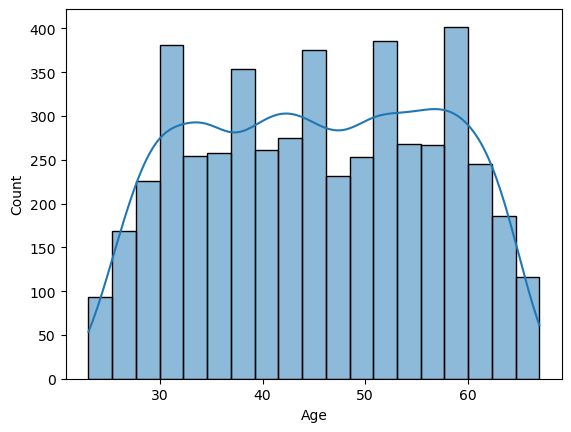

In [13]:
sns.histplot(data=loan_dataset_df, x="Age", kde=True);

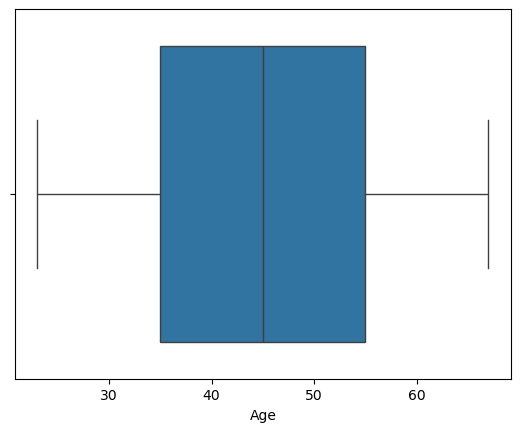

In [14]:
sns.boxplot(data=loan_dataset_df, x="Age");

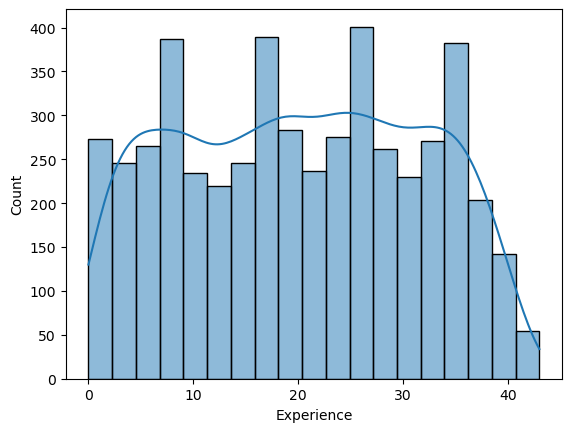

In [15]:
sns.histplot(data=loan_dataset_df, x="Experience", kde=True);

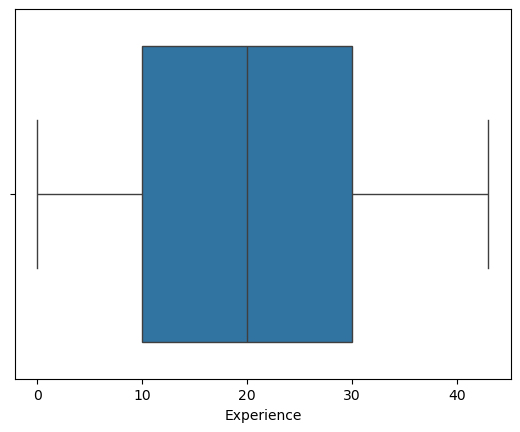

In [16]:
sns.boxplot(data=loan_dataset_df, x="Experience");

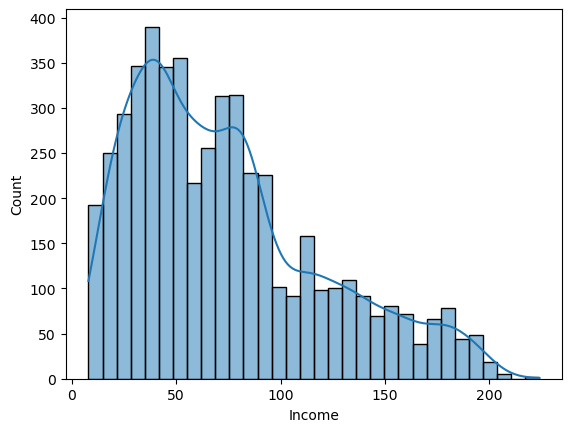

In [17]:
sns.histplot(data=loan_dataset_df, x="Income", kde=True);

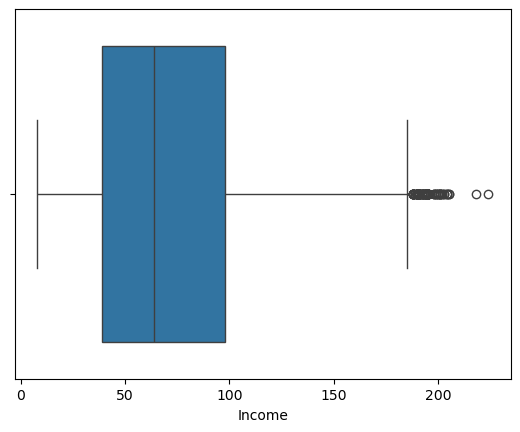

In [18]:
sns.boxplot(data=loan_dataset_df, x="Income");

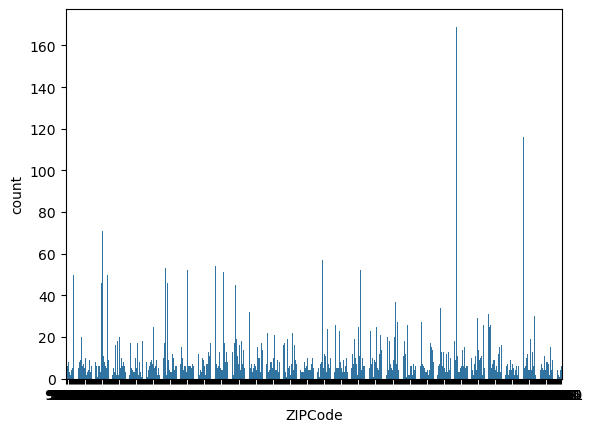

In [19]:
sns.countplot(loan_dataset_df, x="ZIPCode");

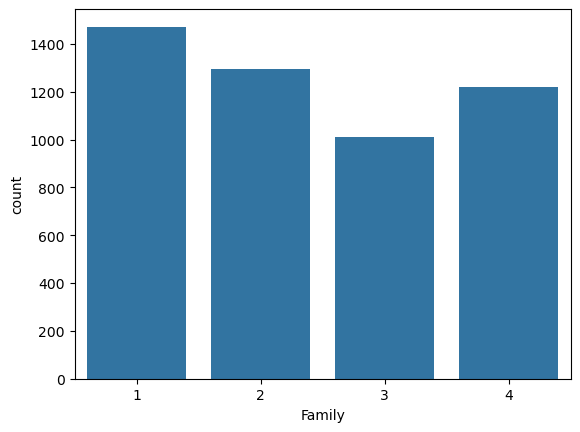

In [20]:
sns.countplot(loan_dataset_df, x="Family");

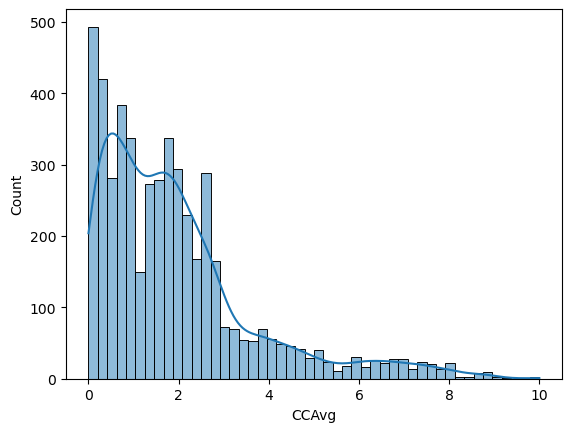

In [21]:
sns.histplot(loan_dataset_df, x="CCAvg", kde=True);

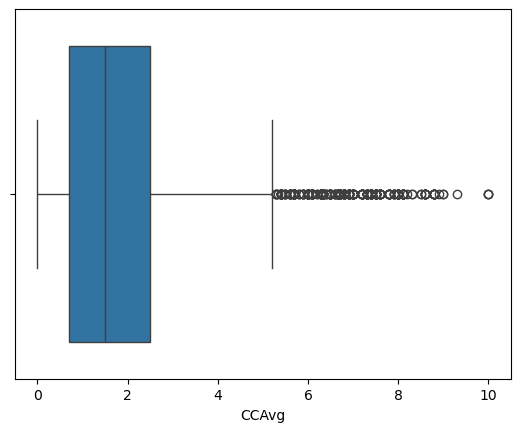

In [22]:
sns.boxplot(loan_dataset_df, x="CCAvg");

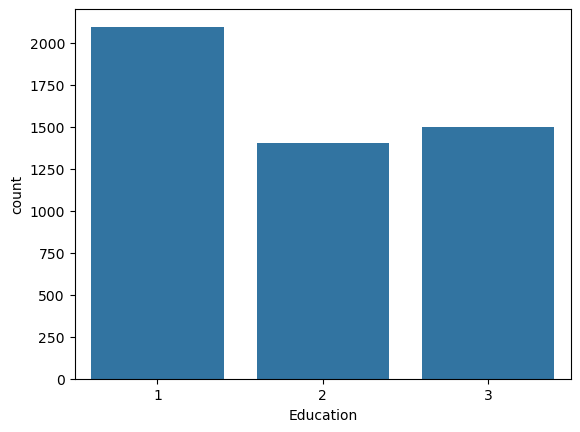

In [23]:
sns.countplot(loan_dataset_df, x="Education");

---
* We have seen above the value_counts for Mortgage is extremely skewed towards value of 0.0
* Normalized values show 69% of entries do not have a mortgage
* Ignoring people with zero mortgage in visualization as it will affect or skew the plots drastically
---

In [24]:
loan_dataset_df.Mortgage.value_counts(normalize=True)

Mortgage
0      0.6924
98     0.0034
89     0.0032
91     0.0032
119    0.0032
        ...  
550    0.0002
283    0.0002
612    0.0002
590    0.0002
541    0.0002
Name: proportion, Length: 347, dtype: float64

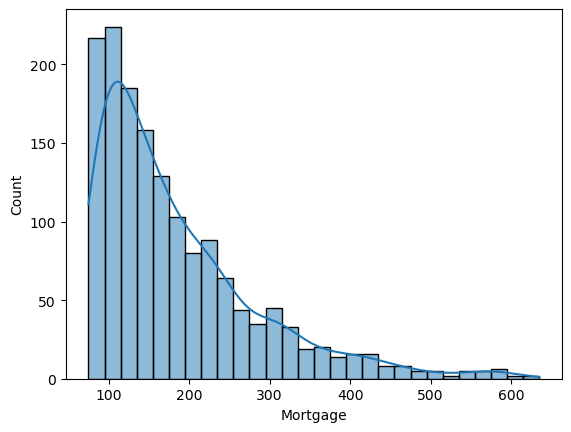

In [25]:
sns.histplot(loan_dataset_df[loan_dataset_df['Mortgage']>0], x="Mortgage", kde=True);

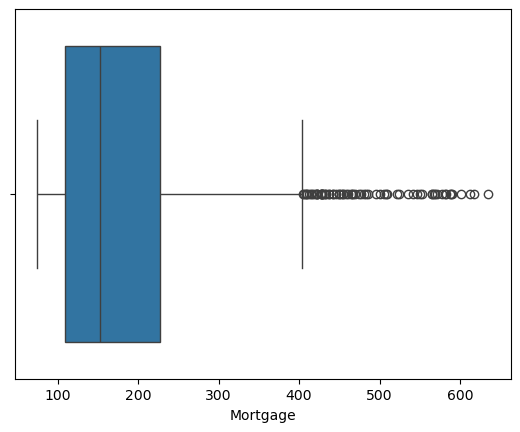

In [26]:
sns.boxplot(loan_dataset_df[loan_dataset_df['Mortgage']>0], x="Mortgage");

---
* Mortgage values which are greater than zero are right skewed distribution with a lot of outliers.
---

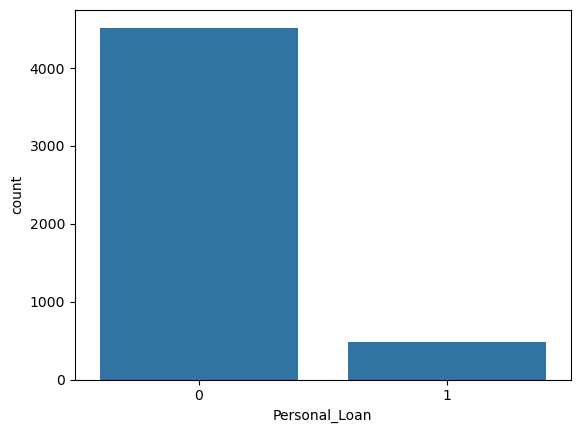

In [27]:
sns.countplot(loan_dataset_df, x="Personal_Loan");

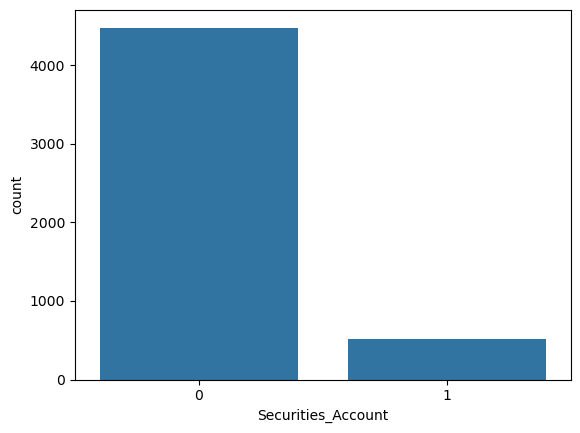

In [28]:
sns.countplot(loan_dataset_df, x="Securities_Account");

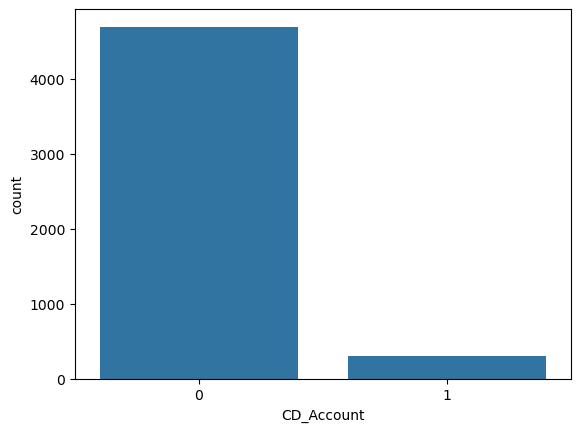

In [29]:
sns.countplot(loan_dataset_df, x="CD_Account");

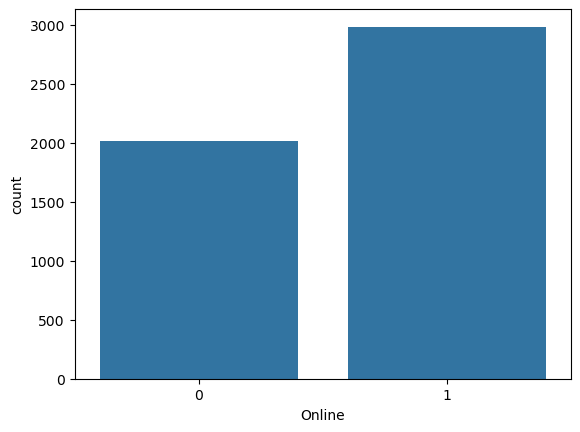

In [30]:
sns.countplot(loan_dataset_df, x="Online");

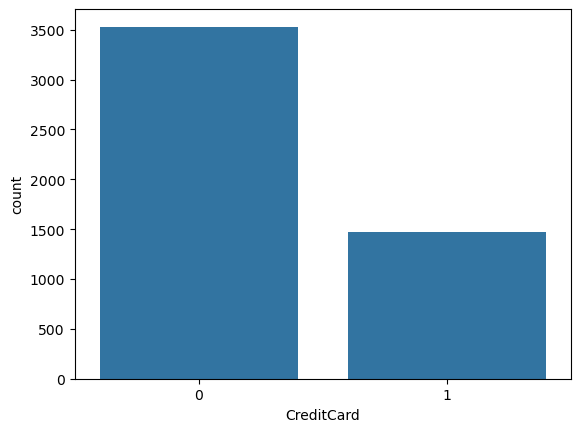

In [31]:
sns.countplot(loan_dataset_df, x="CreditCard");

---
* From the count plot and value counts output earlier, the number of customers with credit card is 3,530
---

In [32]:
df_corr = loan_dataset_df.corr()
df_corr

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
ID,1.000000,-0.008473,-0.008202,-0.017695,0.002240,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.993991,-0.055269,-0.030530,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.008202,0.993991,1.000000,-0.046876,-0.030837,-0.051851,-0.049738,0.013919,-0.011097,-0.008304,-0.000989,0.009735,0.014051,0.008851
Income,-0.017695,-0.055269,-0.046876,1.000000,-0.030709,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIPCode,0.002240,-0.030530,-0.030837,-0.030709,1.000000,0.027512,-0.012188,-0.008266,0.003614,-0.002974,0.002422,0.021671,0.028317,0.024033
Family,-0.016797,-0.046418,-0.051851,-0.157501,0.027512,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.049738,0.645984,-0.012188,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.013919,-0.187524,-0.008266,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.011097,0.206806,0.003614,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal_Loan,-0.024801,-0.007726,-0.008304,0.502462,-0.002974,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


<Axes: >

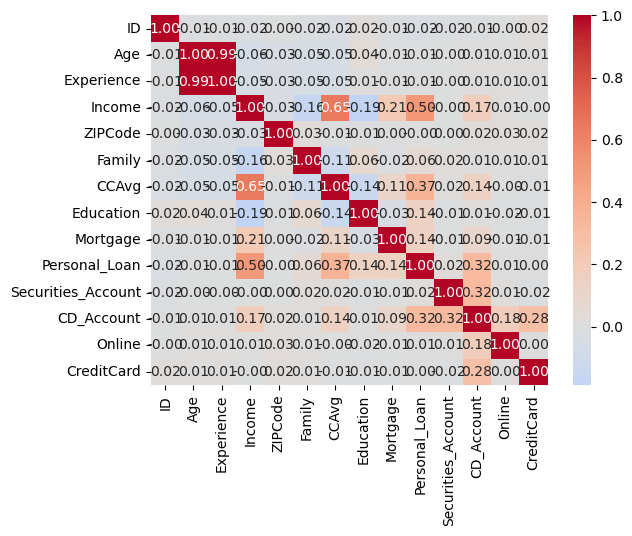

In [33]:
sns.heatmap(df_corr, cmap="coolwarm", annot=True, fmt=".2f", center=0)

---
* Personal Loan highest correlation ranked Income(0.5), CCAvg(0.37) and CD_Account(0.32)
* CCAvg and CD_Account are still weakly and positively correlated
---

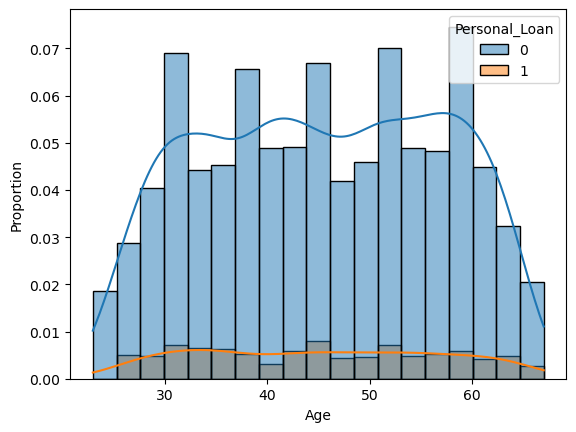

In [34]:
sns.histplot(loan_dataset_df, x='Age', hue='Personal_Loan', stat='proportion', kde=True);

---
* Personal Loan is skewed towards more working age population.
* People in school age and seniors who have retired look like take lesser proportion of personal loans.
---

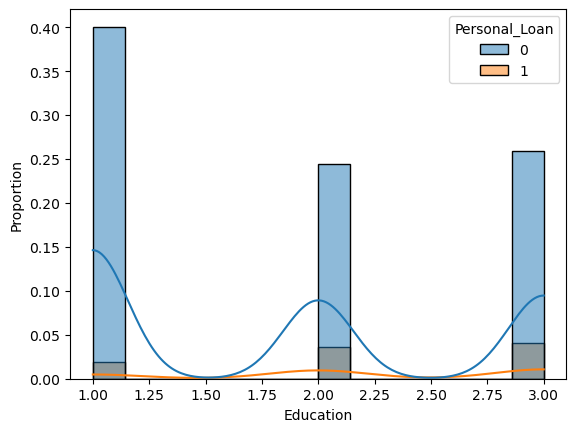

In [35]:
sns.histplot(loan_dataset_df, x='Education', hue='Personal_Loan', stat='proportion', kde=True);

---
* Higher the education level more the proportion of people taking out personal loans
* Education looks to be an important feature or input column to be aware of here
* This might be highly correlated with income too, but that is not the case as in this dataset they are negatively correlated from the correlation matrix(-0.19)
---

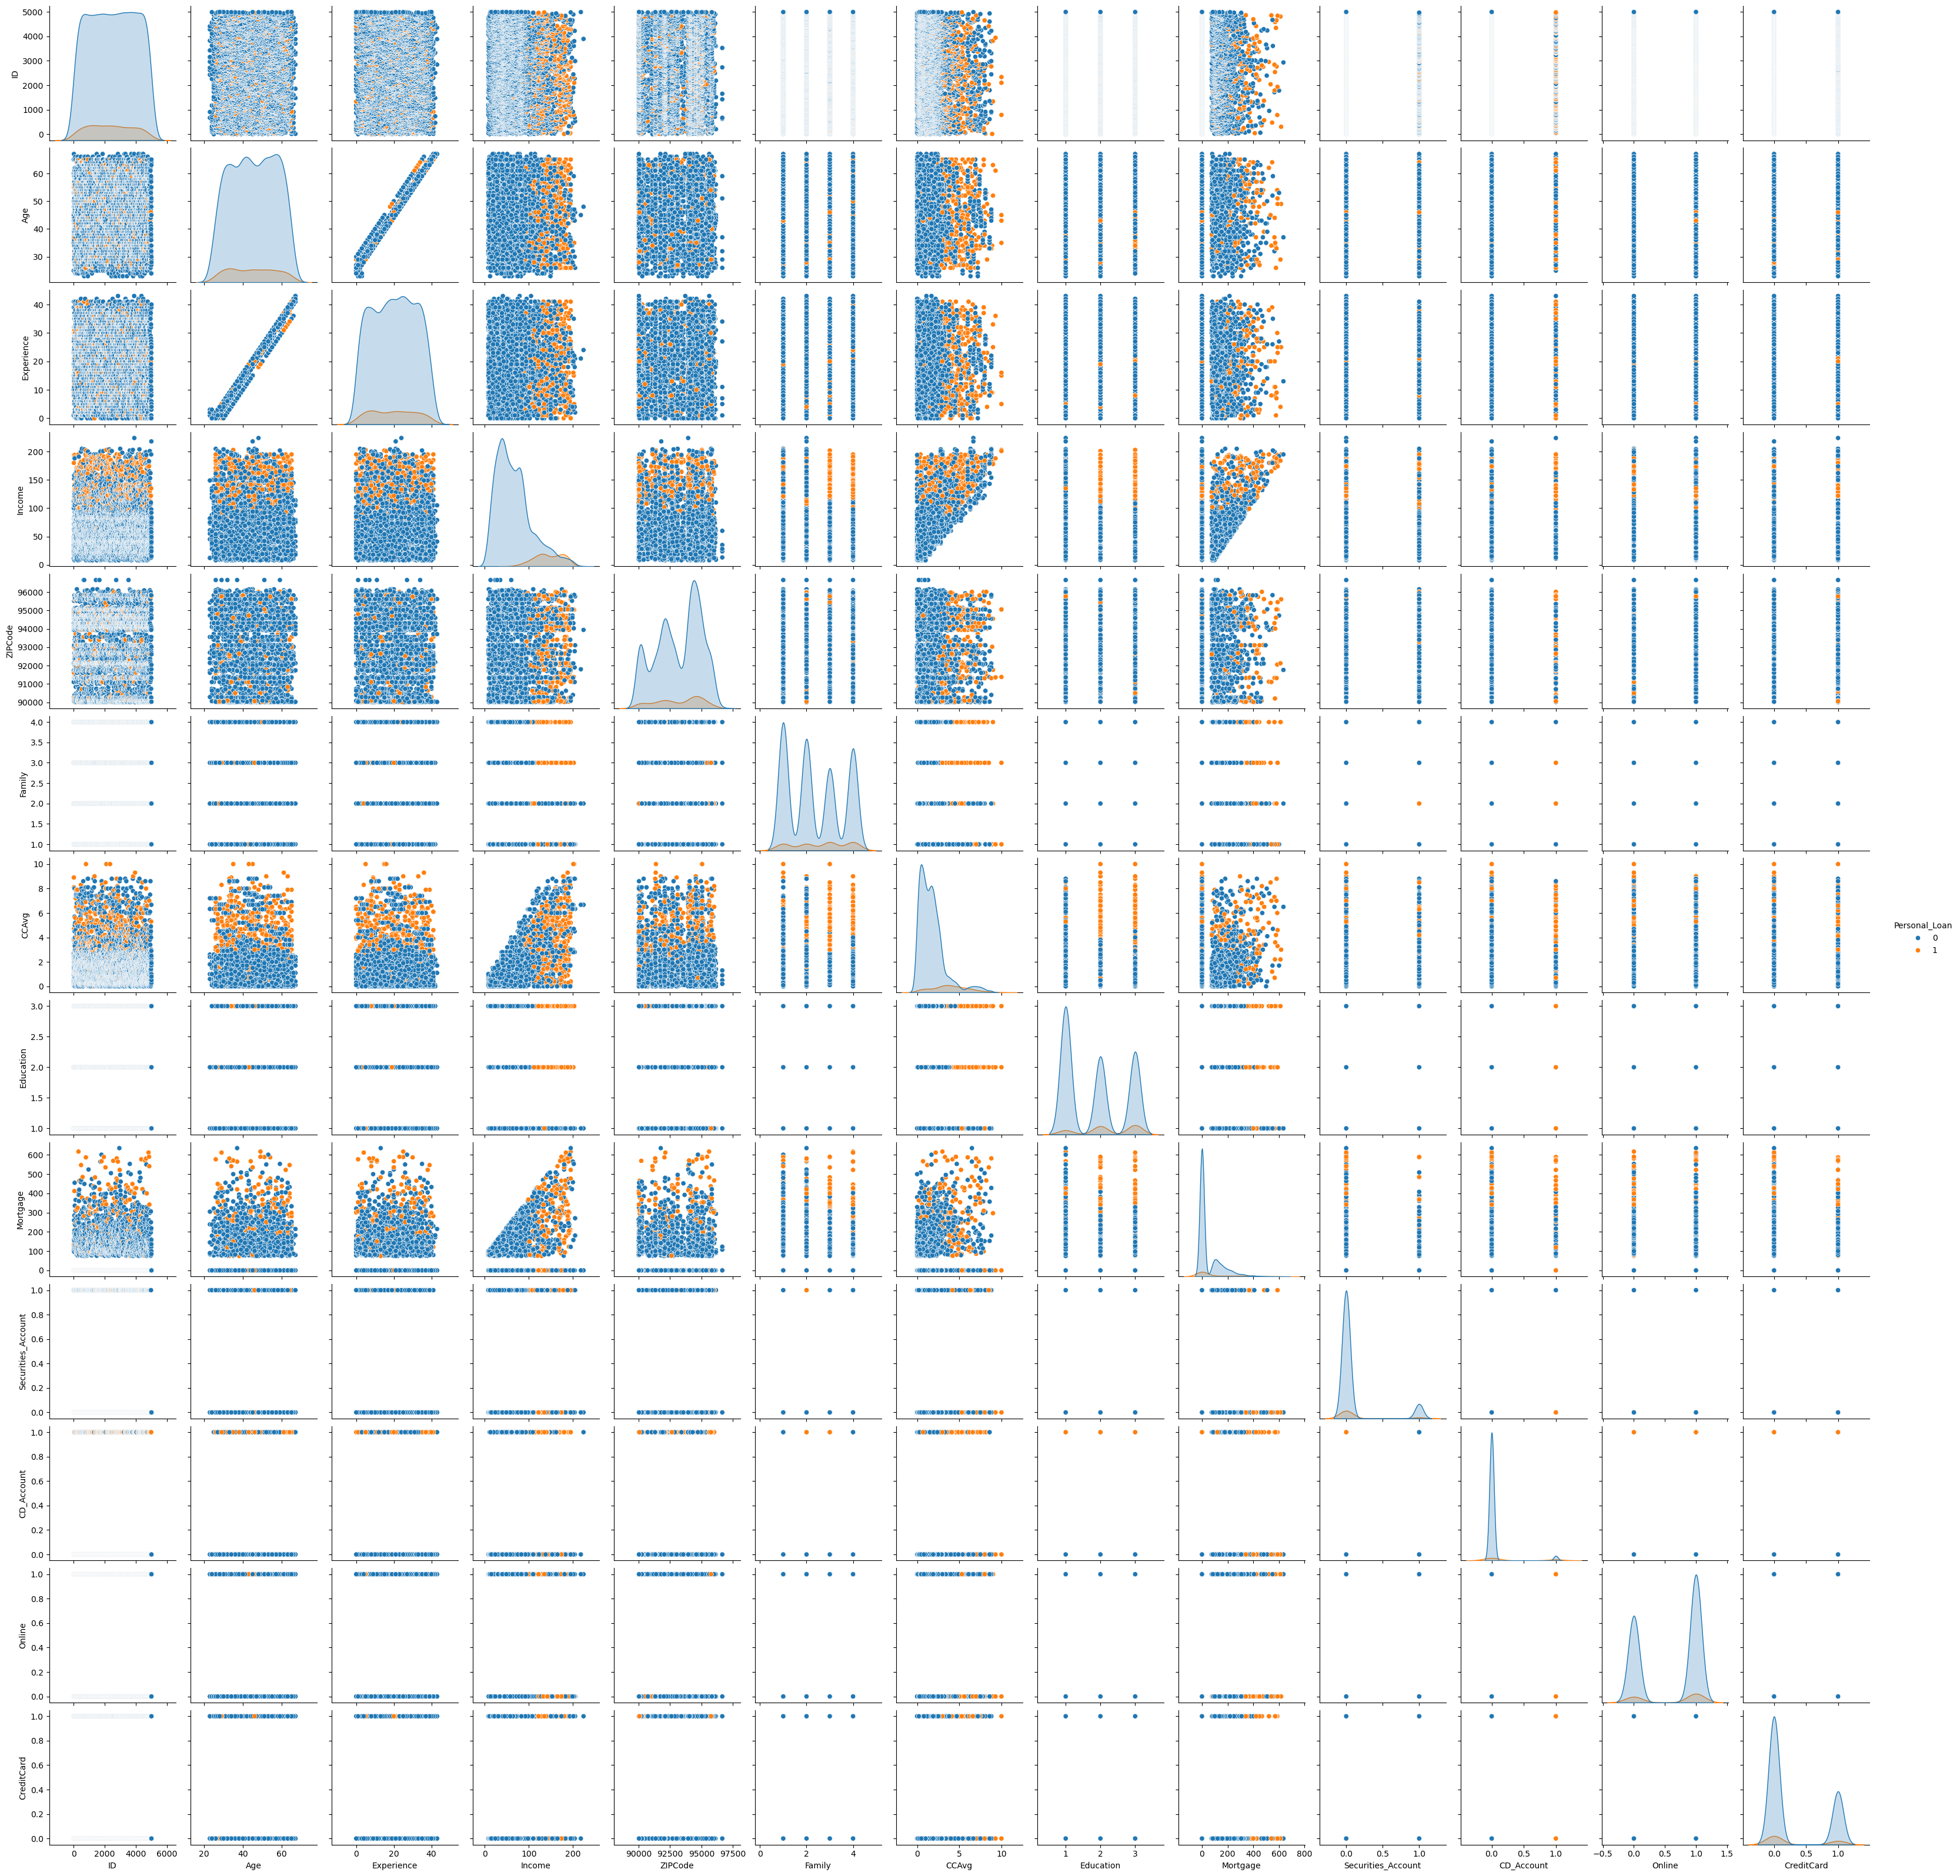

In [36]:
sns.pairplot(loan_dataset_df, hue='Personal_Loan');

---
* Income, CCAvg, Mortgage, Family Sizes show differentiation in perosnal across multiple features
* CD_Account, Online, Education work well features from the above column. These are good candidates for leaf nodes.
* Education for graduate and advanced level look like they work well with the main features in the first bullet point
* We can look at box plots for some of the features with Personal loan as the hue
---

---

* Pairplot of the key features below show some clear boundaries or classifications useful for the decision tree

---

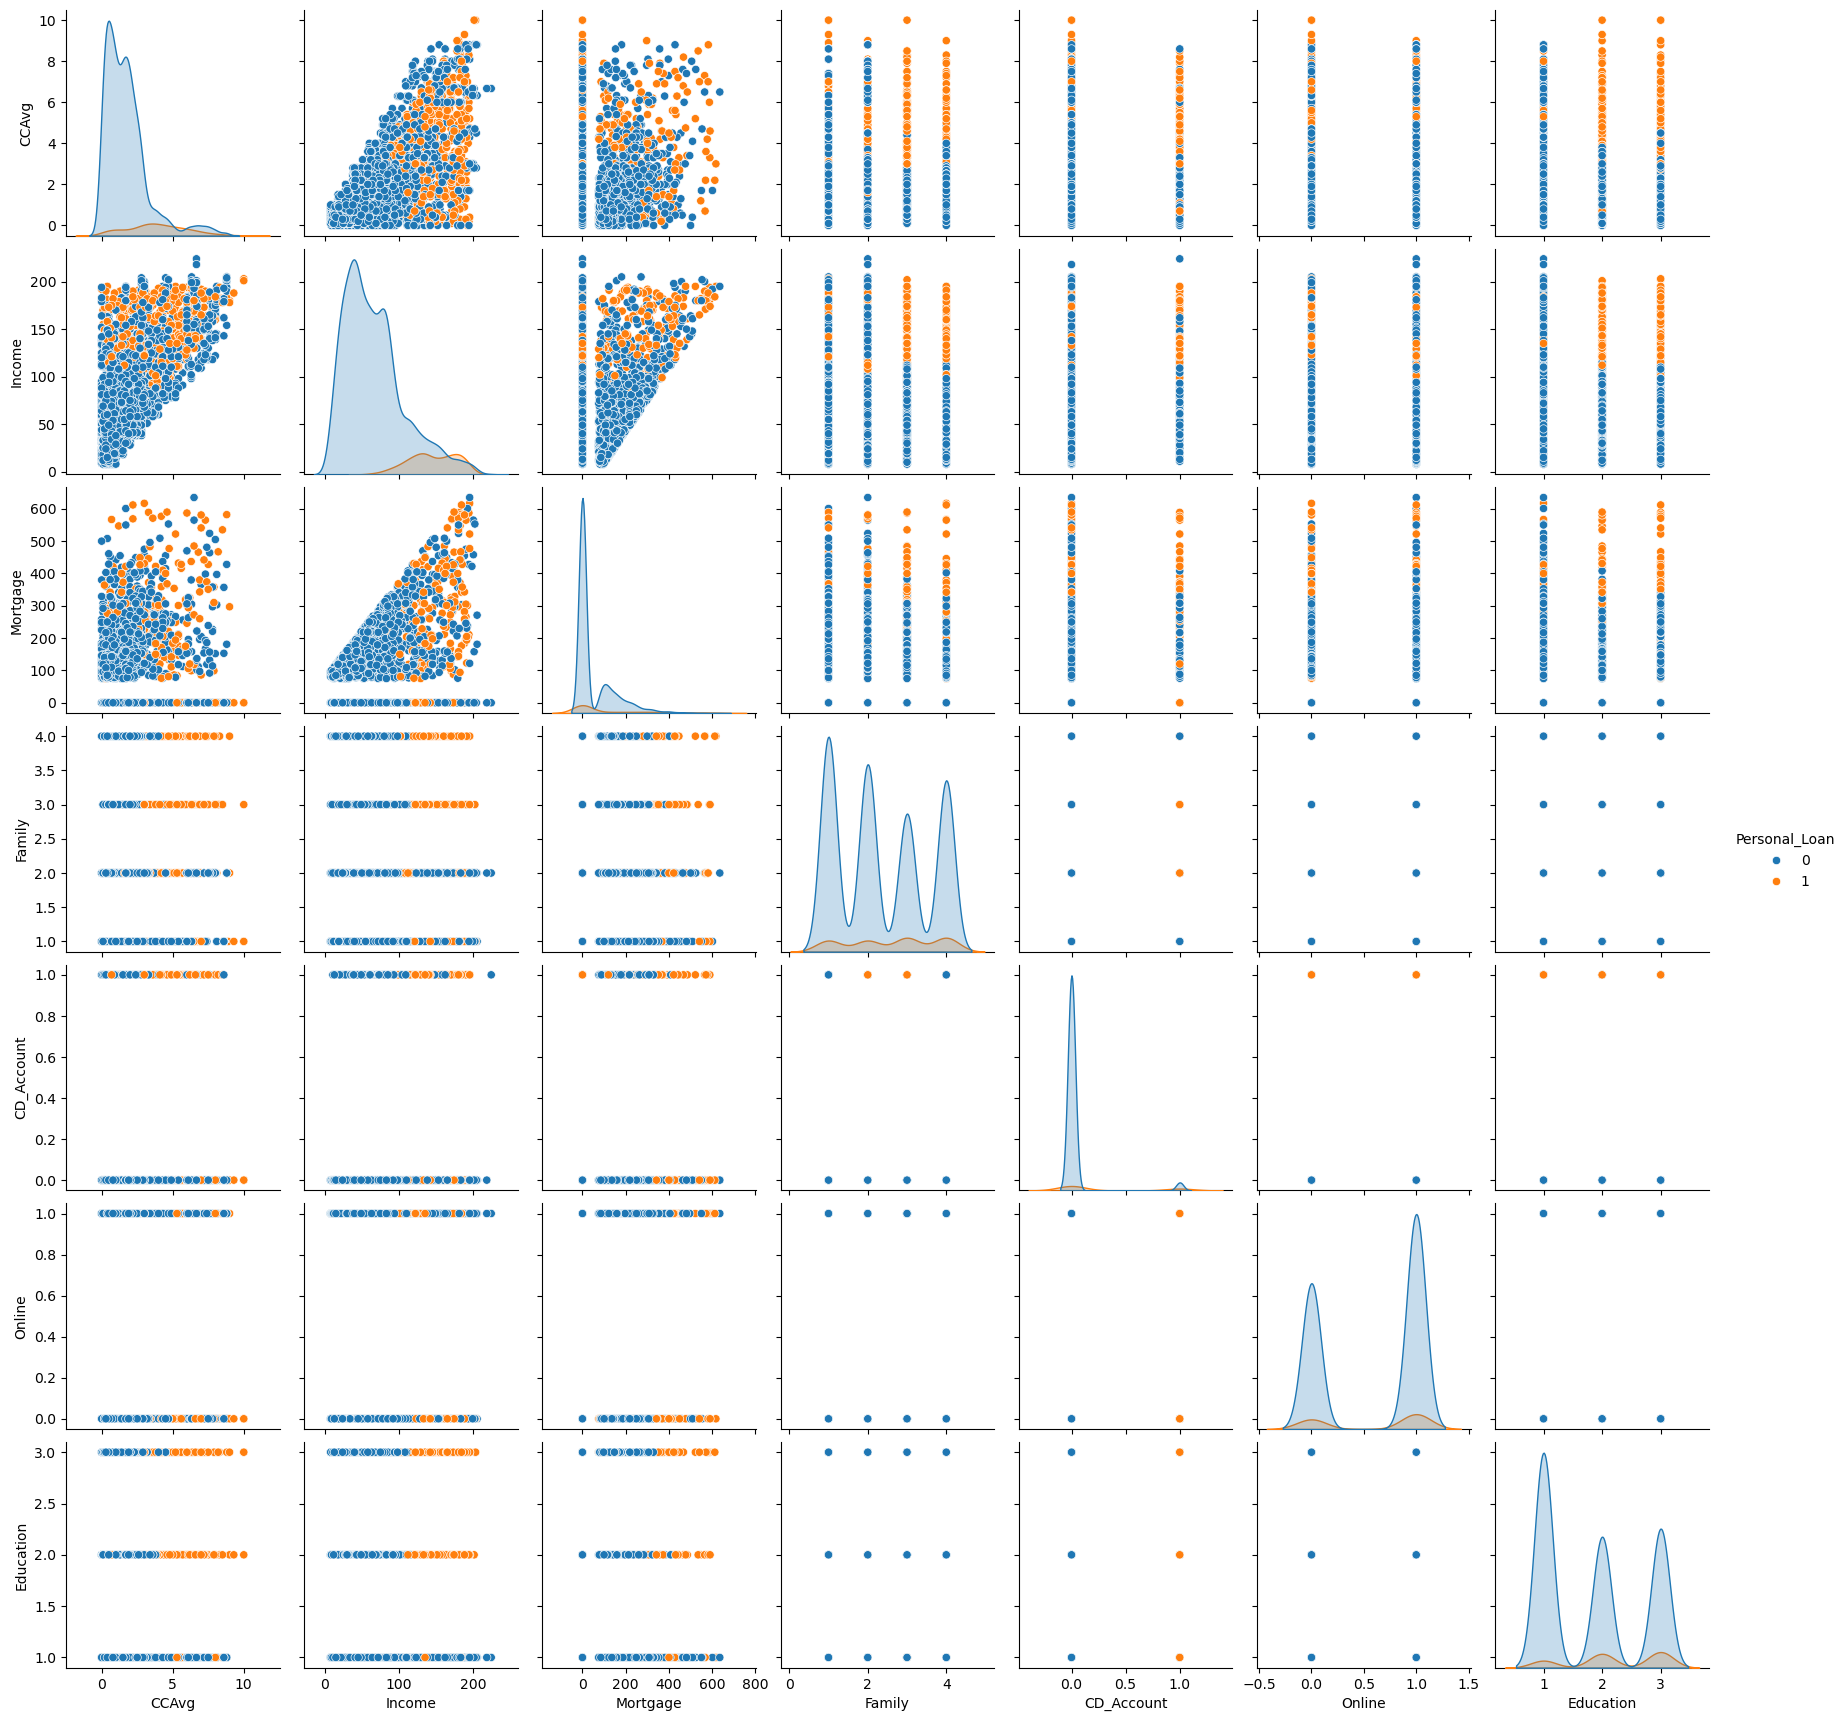

In [37]:
sns.pairplot(loan_dataset_df[['CCAvg', 'Income', 'Mortgage', 'Family', 'CD_Account', 'Online', 'Education', 'Personal_Loan']], hue='Personal_Loan');

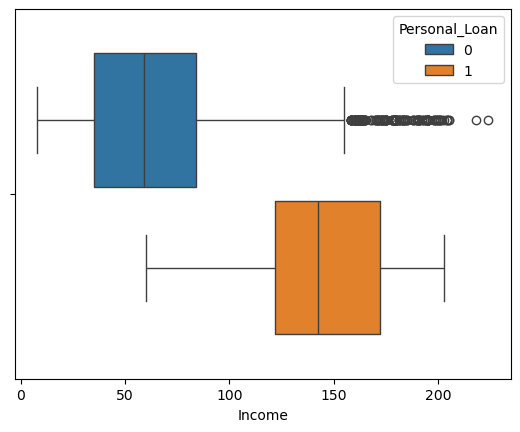

In [38]:
sns.boxplot(loan_dataset_df, x='Income', hue='Personal_Loan', gap=0.1);

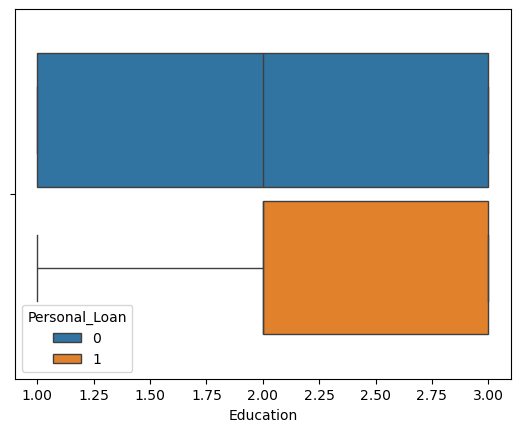

In [39]:
sns.boxplot(loan_dataset_df, x='Education', hue='Personal_Loan', gap=0.1);

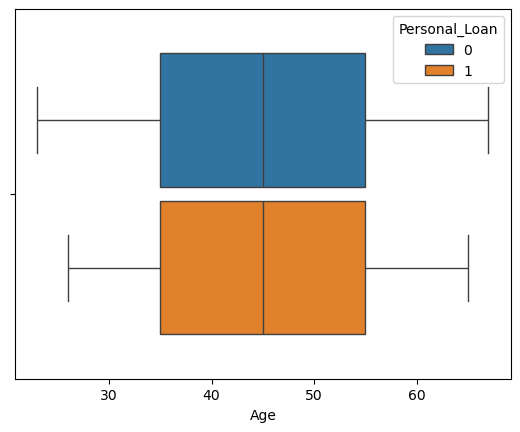

In [40]:
sns.boxplot(loan_dataset_df, x='Age', hue='Personal_Loan', gap=0.1);

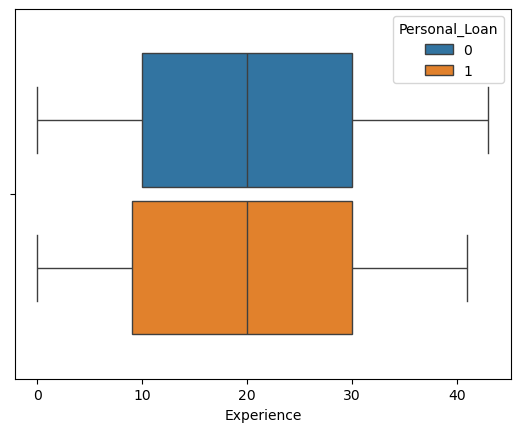

In [41]:
sns.boxplot(loan_dataset_df, x='Experience', hue='Personal_Loan', gap=0.1);

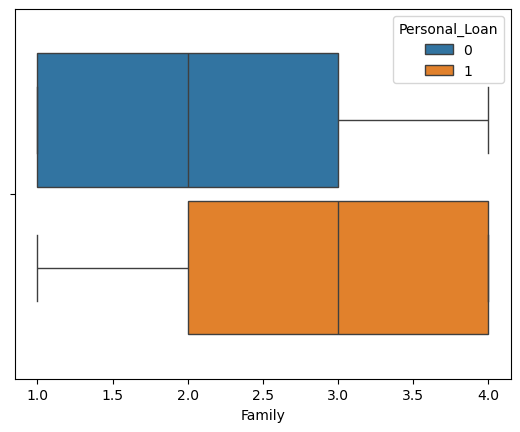

In [42]:
sns.boxplot(loan_dataset_df, x='Family', hue='Personal_Loan', gap=0.1);

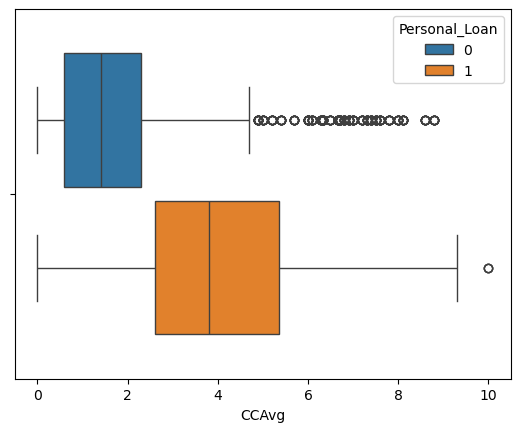

In [43]:
sns.boxplot(loan_dataset_df, x='CCAvg', hue='Personal_Loan', gap=0.1);

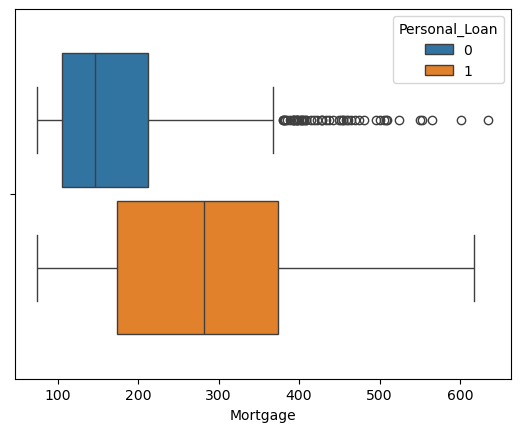

In [44]:
sns.boxplot(loan_dataset_df[loan_dataset_df['Mortgage']>0], x='Mortgage', hue='Personal_Loan', gap=0.1);

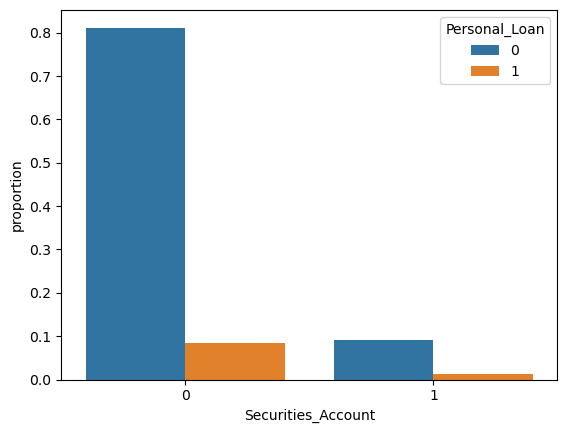

In [45]:
sns.countplot(loan_dataset_df, x='Securities_Account', hue='Personal_Loan', stat='proportion');

---
* From the above boxplots we can see the following categories having an impact on personal loan
    - High CCAvg: People who have no personal loan have CCAvg <$2,500.
      
    - High Income: 75% of people who do not have a personal loan have an Income of less than $90,000.
    
    - Education: People with graduate or advanced degrees seem more likely to get a personal loan.
      
    - Larger families: Large families of 3 or greater have higher chance of taking a personal loan.
 
    - Higher Mortgage balance: close to less than 75 % of families who have no personal loan have less than $200,000 mortgage balance for cases where mortgae balance>0
* Age and Experience are distributed pretty evenly between people with personal loan or not
* Weak relationship of higher propotion of folks having a security accoung getting a personal loan
* CD_Account, Online and Education work well with the above 4 features.
* Building a decision tree using the 4 main and 3 secondary features. Additional are possible after checking the zipcode attributes.
---

#### Above analysis shows how to process features for the decision tree

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

---
* Already treated years of experience earlier in EDA
* Use zipcode data
    - Check if valid values of zipcode are available
    -  Setup a column to see if it belongs to a city or not
    -  Determine if it is a Metor area. Population density of greater than 1000 considered Metro. From Brittanica Encyclopedia [description](https://www.britannica.com/topic/metropolitan-area).
---

In [46]:
from uszipcode import SearchEngine
search = SearchEngine()
def validate_zipcode(zipcode): 
    # Check if the zip code is in the database and return True or False
    return bool(search.by_zipcode(zipcode))

def zco(x):
    city_flag=1
    try:
        city = search.by_zipcode(x).major_city
    except AttributeError:
        city_flag=0
    
    return city_flag

def pop_density(x):
    return search.by_zipcode(x).population_density

def population(x):
    return search.by_zipcode(x).population
    

def household_income(x):
    return search.by_zipcode(x).median_household_income
def home_value(x):
    return search.by_zipcode(x).median_home_value
def house_w_kids(x):
    return search.by_zipcode(x).households_with_kids

C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [47]:
loan_dataset_df['ZIPCode_Exists'] = loan_dataset_df['ZIPCode'].apply(validate_zipcode)
loan_dataset_df['ZIPCode_Exists'].value_counts()

ZIPCode_Exists
True     4966
False      34
Name: count, dtype: int64

In [48]:
loan_dataset_df[loan_dataset_df['ZIPCode_Exists']==True].ZIPCode.value_counts(normalize=True)

ZIPCode
94720    0.034031
94305    0.025574
95616    0.023359
90095    0.014297
93106    0.011478
           ...   
90068    0.000201
94970    0.000201
90813    0.000201
94404    0.000201
94598    0.000201
Name: proportion, Length: 463, dtype: float64

In [49]:
loan_dataset_df[loan_dataset_df['ZIPCode_Exists']==False]

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,ZIPCode_Exists
106,107,43,17,69,92717,4,2.90,1,0,0,0,0,1,1,False
172,173,38,13,171,92717,2,7.80,1,0,0,0,0,1,0,False
184,185,52,26,63,92717,2,1.50,2,0,0,1,0,1,0,False
321,322,44,20,101,92717,3,4.40,2,82,1,0,0,0,0,False
366,367,50,24,35,92717,1,0.30,3,0,0,0,0,1,0,False
384,385,51,25,21,93077,4,0.60,3,0,0,0,0,1,1,False
468,469,34,10,21,92634,1,0.50,3,0,0,0,0,1,0,False
476,477,60,34,53,92717,1,0.80,2,0,0,1,0,0,1,False
630,631,32,7,35,96651,3,1.30,1,108,0,0,0,0,1,False
672,673,51,27,23,96651,1,0.20,1,0,0,0,0,1,0,False


---
* The most popular zipcodes from normalized value counts are not close to the values of zipcodes which could not be validated
* Dropping rows of zipcodes which could not be validated
---

In [50]:
loan_dataset_df['City'] = loan_dataset_df['ZIPCode'].apply(zco)
print(loan_dataset_df['City'].value_counts())

City
1    4966
0      34
Name: count, dtype: int64


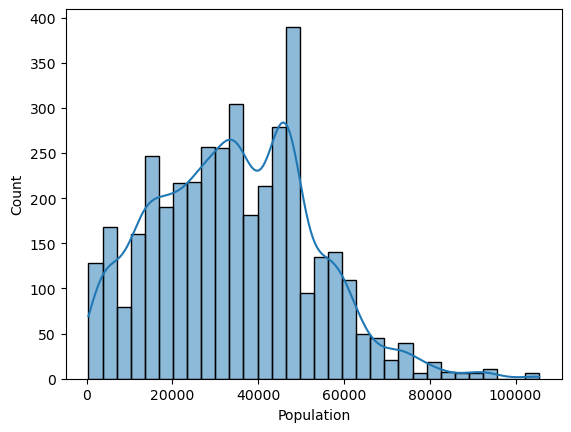

In [51]:
loan_dataset_df['Population'] = loan_dataset_df['ZIPCode'][loan_dataset_df['ZIPCode_Exists']==True].apply(population)
sns.histplot(data=loan_dataset_df, x="Population", kde=True);

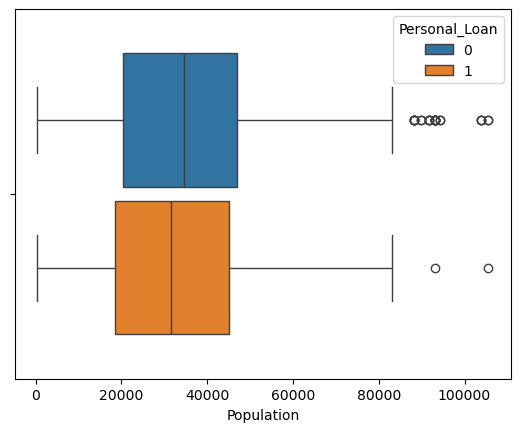

In [52]:
sns.boxplot(loan_dataset_df, x='Population', hue='Personal_Loan', gap=0.1);

In [53]:
loan_dataset_df['PopulationDensity'] = loan_dataset_df['ZIPCode'][loan_dataset_df['ZIPCode_Exists']==True].apply(pop_density)
loan_dataset_df['PopulationDensity'].value_counts()

PopulationDensity
2703.0     127
1707.0     116
3577.0      54
2426.0      53
2379.0      52
          ... 
3698.0       1
2925.0       1
18360.0      1
7923.0       1
1693.0       1
Name: count, Length: 393, dtype: int64

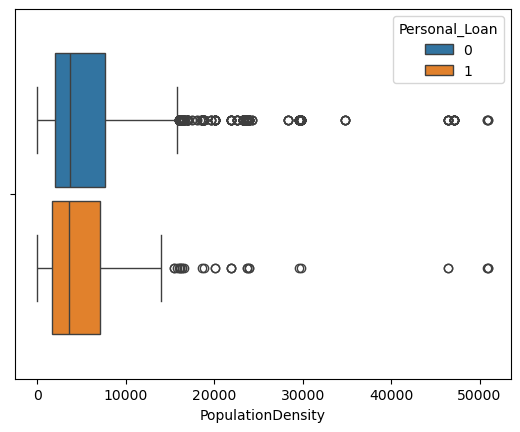

In [54]:
sns.boxplot(loan_dataset_df, x='PopulationDensity', hue='Personal_Loan', gap=0.1);

In [55]:
loan_dataset_df['Household_Income'] = loan_dataset_df['ZIPCode'][loan_dataset_df['ZIPCode_Exists']==True].apply(household_income)

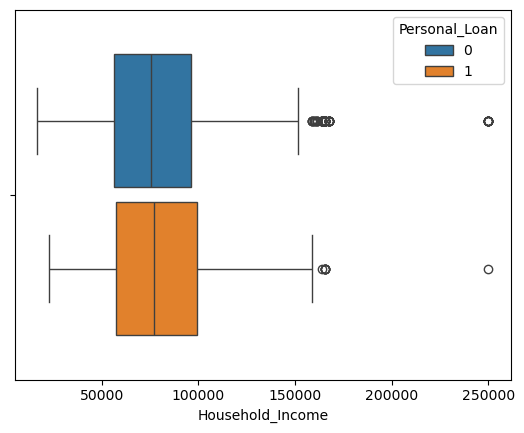

In [56]:
sns.boxplot(loan_dataset_df, x='Household_Income', hue='Personal_Loan', gap=0.1);

In [57]:
loan_dataset_df['Median_Home_Value'] = loan_dataset_df['ZIPCode'][loan_dataset_df['ZIPCode_Exists']==True].apply(home_value)

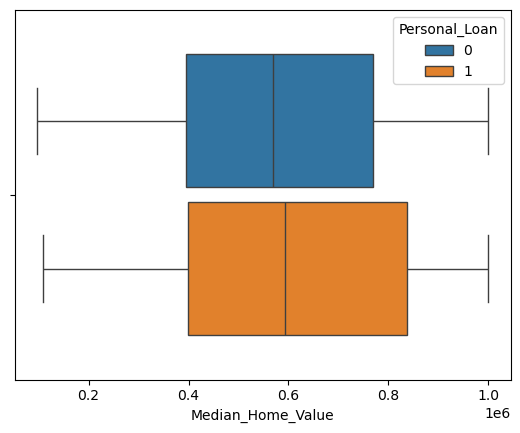

In [58]:
sns.boxplot(loan_dataset_df, x='Median_Home_Value', hue='Personal_Loan', gap=0.1);

---
* Removed 34 columns of zipcodes which do not have validated zip codes as we will not be validate where the customers are 
* Looked at city, population, population_density, median_home_value and Median Household Income. These do not show significant trends
---

---
* Adding features based on what we found on EDA for personal loan
    - High CCAvg: People who have no personal loan have CCAvg <$2,500.
      
    - High Income: 75% of people who do not have a personal loan have an Income of less than $90,000.
    
    - Education: People with graduate or advanced degrees seem more likely to get a personal loan.
      
    - Larger families: Large families of 3 or greater have higher chance of taking a personal loan.
 
    - Higher Mortgage balance: close to less than 75 % of families who have no personal loan have less than $200,000 mortgage balance for cases where mortgae balance>0
 
    - Education greater than or equal to 2
 
    - Online Account and CD_Account are already 0 and 1
---

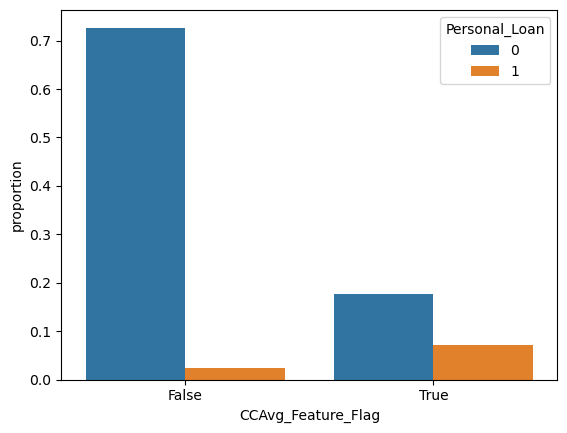

In [59]:
loan_dataset_df['CCAvg_Feature_Flag'] = loan_dataset_df['CCAvg']>2.5
sns.countplot(loan_dataset_df, x='CCAvg_Feature_Flag', hue='Personal_Loan', stat='proportion');

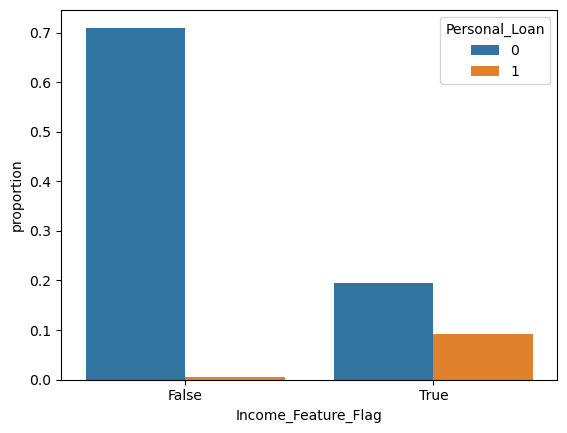

In [60]:
loan_dataset_df['Income_Feature_Flag'] = loan_dataset_df['Income']>90
sns.countplot(loan_dataset_df, x='Income_Feature_Flag', hue='Personal_Loan', stat='proportion');

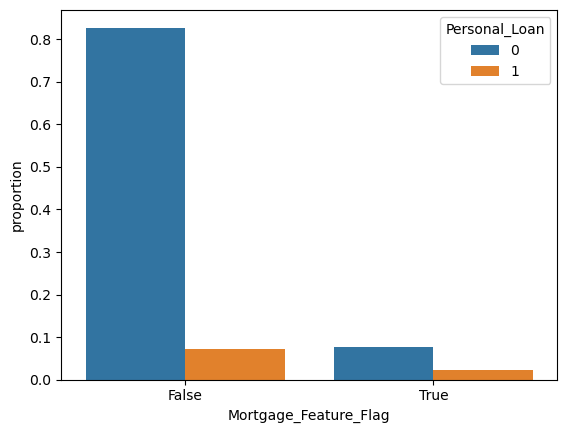

In [61]:
loan_dataset_df['Mortgage_Feature_Flag'] = loan_dataset_df['Mortgage']>200
sns.countplot(loan_dataset_df, x='Mortgage_Feature_Flag', hue='Personal_Loan', stat='proportion');

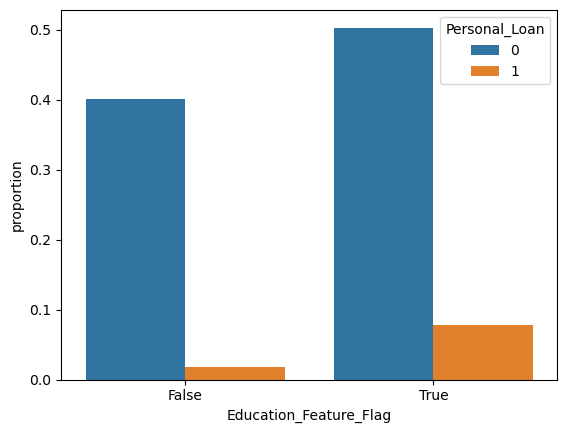

In [62]:
loan_dataset_df['Education_Feature_Flag'] = loan_dataset_df['Education']>=2
sns.countplot(loan_dataset_df, x='Education_Feature_Flag', hue='Personal_Loan', stat='proportion');

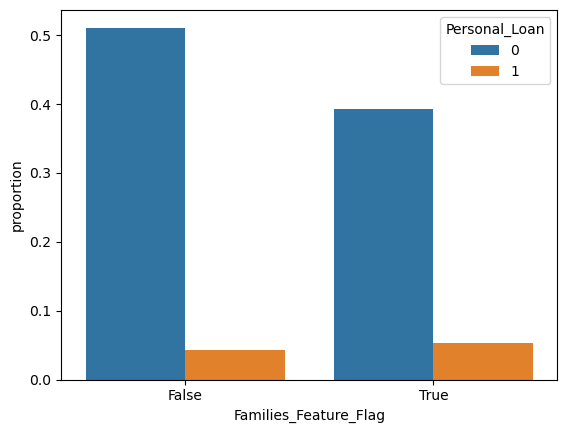

In [63]:
loan_dataset_df['Families_Feature_Flag'] = loan_dataset_df['Family']>=3
sns.countplot(loan_dataset_df, x='Families_Feature_Flag', hue='Personal_Loan', stat='proportion');

* Dropping the rows of ZipCode which could not be validated from the analysis

In [64]:
processed_loan_dataset_df=loan_dataset_df[loan_dataset_df['ZIPCode_Exists']==True]

---
#### Data Preparation
---

In [65]:
features_list = ['CCAvg_Feature_Flag', 
                 'Income_Feature_Flag', 
                 'Mortgage_Feature_Flag', 
                 'Families_Feature_Flag', 
                 'CD_Account', 
                 'Online', 
                 'Education_Feature_Flag']
X = processed_loan_dataset_df[features_list]
X.sample(10)

,CCAvg_Feature_Flag,Income_Feature_Flag,Mortgage_Feature_Flag,Families_Feature_Flag,CD_Account,Online,Education_Feature_Flag
3134,False,False,False,False,0,1,False
660,True,True,False,False,0,1,False
1569,False,False,False,True,0,0,True
2850,True,True,True,False,0,0,False
4908,True,True,False,False,0,1,False
3405,False,False,False,False,0,1,True
3880,False,False,False,True,0,0,True
484,False,True,False,False,0,1,False
2470,True,False,False,False,1,1,True
4418,False,True,False,True,0,1,False


In [66]:
y = processed_loan_dataset_df['Personal_Loan']
y.sample(10)

3710    0
2751    0
2977    0
4960    0
2501    0
790     0
3507    0
3164    0
3929    0
3400    0
Name: Personal_Loan, dtype: int64

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.25, 
                                                    random_state=42)
print(f'Shape of X_train is: {X_train.shape}')
print(f'Shape of X_train is: {X_test.shape}')
print(f'Shape of X_train is: {y_train.shape}')
print(f'Shape of X_train is: {y_test.shape}')

Shape of X_train is: (3724, 7)
Shape of X_train is: (1242, 7)
Shape of X_train is: (3724,)
Shape of X_train is: (1242,)


* Check if stratification is needed

In [68]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
Personal_Loan
0    0.902793
1    0.097207
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.907407
1    0.092593
Name: proportion, dtype: float64


* Stratification is not needed since train and test splits have similar distribution of personal loans

## Model Building

### Model Evaluation Criterion

* Since we would like to reduce the amount of False Positives to avoid financial losses incurred.

* In this case Precision is good measure to consider. That is we do not want to provide loans to folks who will not be good candidates.

* There is a case to balance False positives and False negatives here too, since a false negative will take us away from marketing to potential customers who might not be contacted.

* F-1 score will give us the balance we need

* Gathering already defined functions from previous notebooks


In [69]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = round(accuracy_score(target, pred), 4)  # to compute Accuracy
    recall = round(recall_score(target, pred), 4)  # to compute Recall
    precision = round(precision_score(target, pred), 4)  # to compute Precision
    f1 = round(f1_score(target, pred), 4)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [70]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building

---
#### Default Decision Tree
---

In [71]:
default_tree = DecisionTreeClassifier(criterion="gini", random_state=42)
default_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

---
* Training the model
---

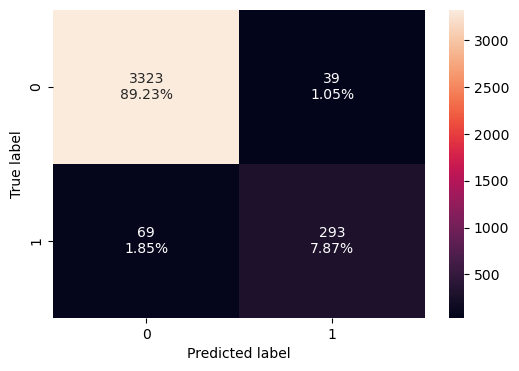

In [72]:
confusion_matrix_sklearn(default_tree, X_train, y_train)

In [73]:
default_tree_perf_train = model_performance_classification_sklearn(default_tree, 
                                                                   X_train, 
                                                                   y_train
                                                                  )
default_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.971,0.8094,0.8825,0.8444


---
* Validating the model on Test Set
---

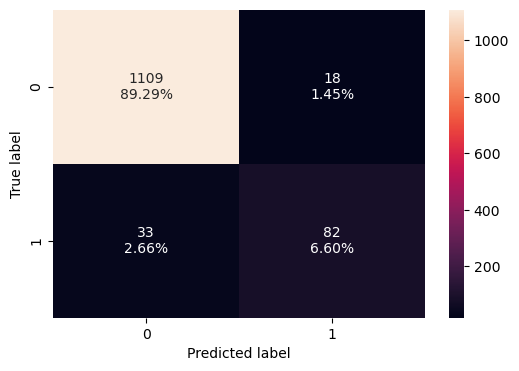

In [74]:
confusion_matrix_sklearn(default_tree, X_test, y_test)

In [75]:
default_tree_perf_test = model_performance_classification_sklearn(default_tree, 
                                                                  X_test, 
                                                                  y_test
                                                                  )
default_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.9589,0.713,0.82,0.7628


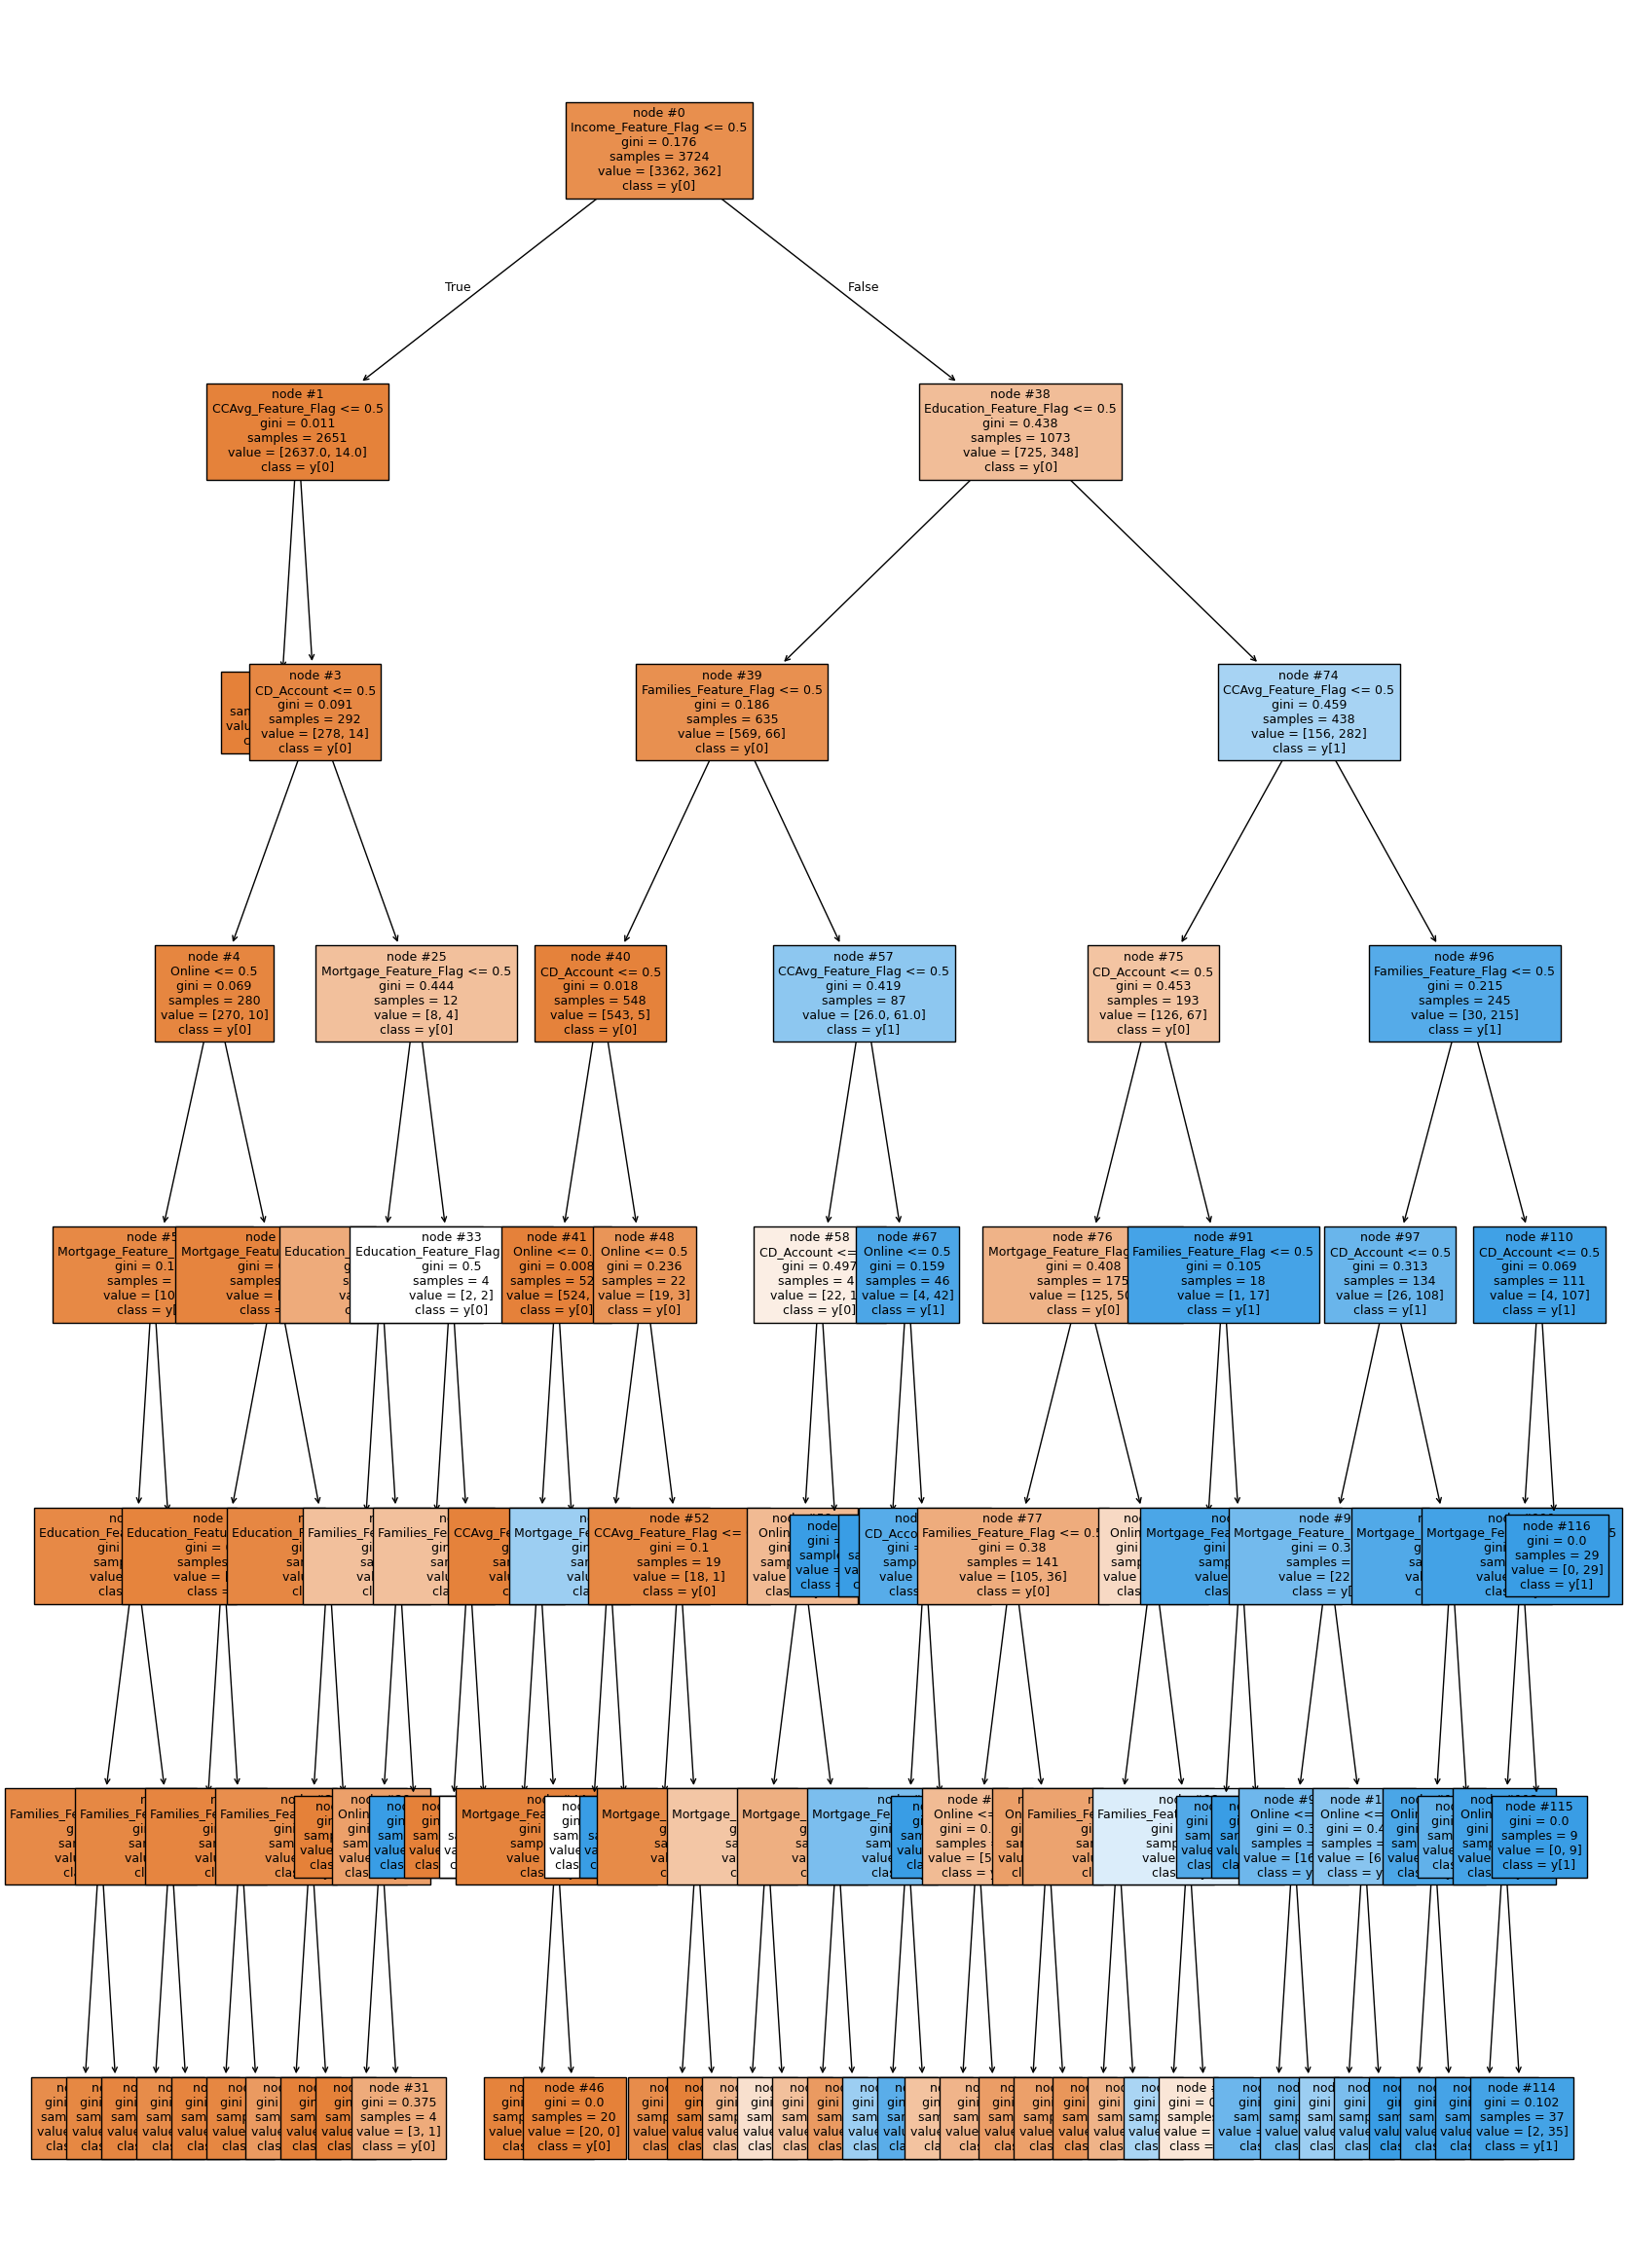

In [76]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    default_tree,
    feature_names=features_list,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

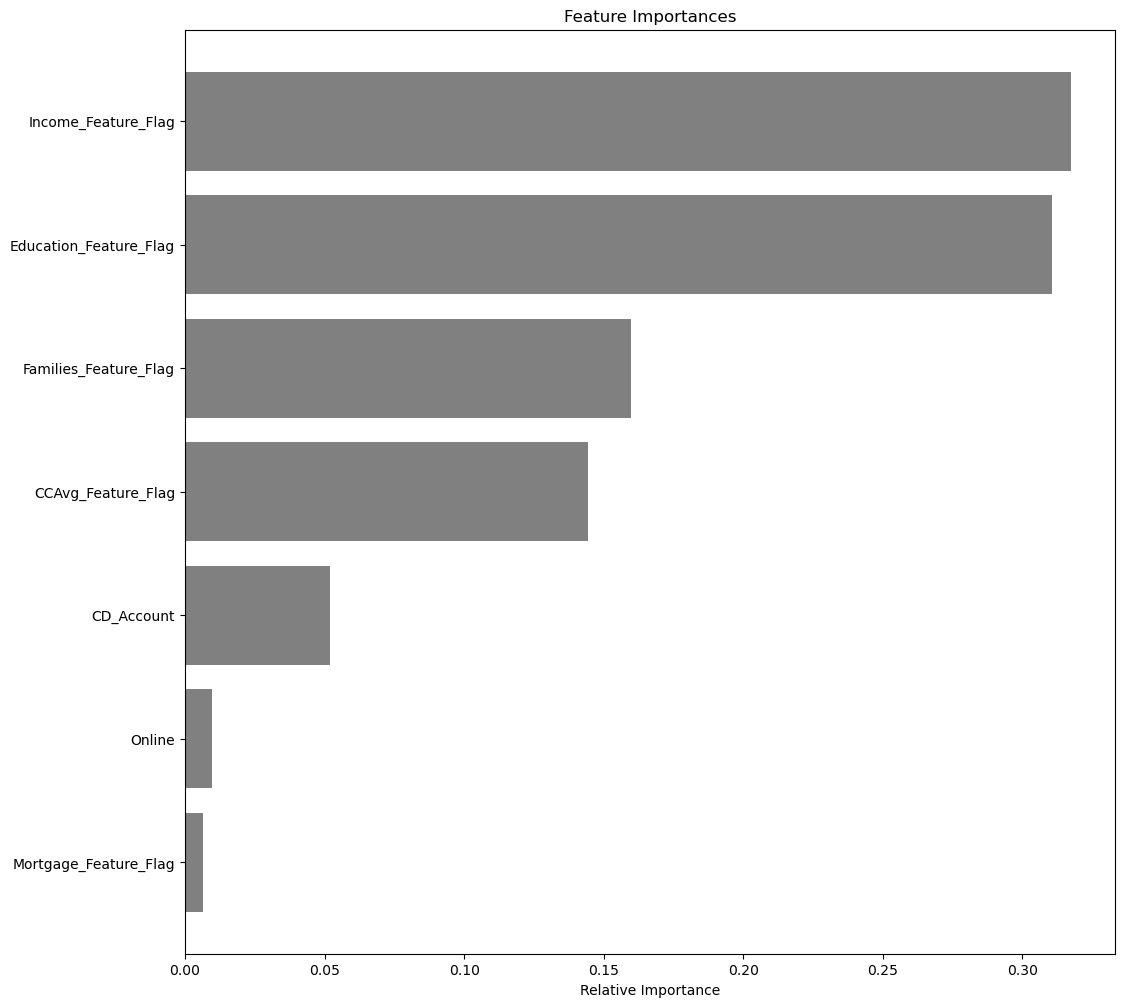

In [77]:
default_tree_importances = default_tree.feature_importances_
indices = np.argsort(default_tree_importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), default_tree_importances[indices], color="grey", align="center")
plt.yticks(range(len(indices)), [features_list[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* My intial assumptions about features were incorrect from the visualization
* Correlation showed income to be the strongest and that is the case here
* CCAvg, Mortgage are smaller
* Education seems to be a major one and Families was correctly predicted from visualization

---
* Training data F-1 Score of 0.8444
* Testing data F-1 Score of 0.7628
* Room for improvement in getting the training data score up and improving the testing data F-1 Score closer to Training data
---

## Model Performance Improvement

---

#### Utilize Pre-pruning first to see model performance

---

In [78]:
# Define the parameters of the tree to iterate over
criterion_list=['gini', 'entropy', 'log_loss']
max_depth_list = [2, 3, 4, 5, 6, 7, 8]
min_samples_leaf_list = [2, 4, 8, 12, 24, 48]
min_samples_split_list = [2, 4, 8, 12, 24, 48] # Lowest leaf node has 20
max_leaf_nodes_list = [2, 4, 8, 12, 24]


# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = 10000000.0
best_test_score = 0.0
best_train_score= 0.0

# Iterate over all combinations of the specified parameter values
for criterion in criterion_list:
    for max_depth in max_depth_list:
        for min_samples_leaf in min_samples_leaf_list:
            for min_samples_split in min_samples_split_list:
                for max_leaf_nodes in max_leaf_nodes_list:

                    # Initialize the tree with the current set of parameters
                    estimator = DecisionTreeClassifier(criterion=criterion,
                                                       max_depth=max_depth,
                                                       min_samples_split=min_samples_split,
                                                       min_samples_leaf=min_samples_leaf,
                                                       max_leaf_nodes=max_leaf_nodes,
                                                       class_weight='balanced',
                                                       random_state=42
                                                      )

                    # Fit the model to the training data
                    estimator.fit(X_train, y_train)
        
                    # Make predictions on the training and test sets
                    y_train_pred = estimator.predict(X_train)
                    y_test_pred = estimator.predict(X_test)
        
                    # Calculate F-1 scores for training and test sets
                    train_f1_score = round(f1_score(y_train, y_train_pred), 4)
                    test_f1_score = round(f1_score(y_test, y_test_pred), 4)
                    
                    # Calculate the absolute difference between training and test F-1 scores
                    score_diff = abs(train_f1_score - test_f1_score)
        
                    # Update the best estimator and best score if the current one has a smaller score difference
                    if (score_diff < best_score_diff) & (test_f1_score > best_test_score):
                        best_score_diff = score_diff
                        best_test_score = test_f1_score
                        best_train_score = train_f1_score
                        best_estimator = estimator

# creating an instance of the best model
best_pre_pruned_tree = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Criterion: {best_pre_pruned_tree.criterion}")
print(f"Max depth: {best_pre_pruned_tree.max_depth}")
print(f"Min samples split: {best_pre_pruned_tree.min_samples_split}")
print(f"Min samples per leaf: {best_pre_pruned_tree.min_samples_leaf}")
print(f"Max leaf nodes: {best_pre_pruned_tree.max_leaf_nodes}")
print(f"Best train F-1 score: {best_train_score}")
print(f"Best test F-1 score: {best_test_score}")

Best parameters found:
Criterion: gini
Max depth: 3
Min samples split: 2
Min samples per leaf: 2
Max leaf nodes: 4
Best train F-1 score: 0.7734
Best test F-1 score: 0.7766


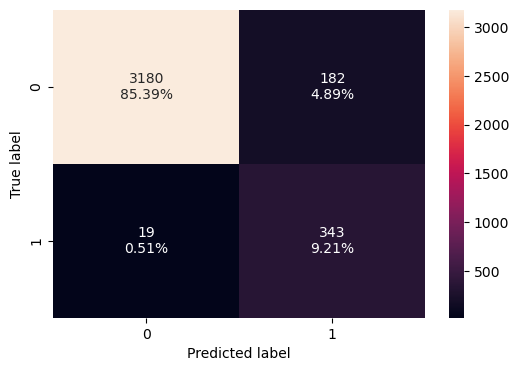

In [79]:
confusion_matrix_sklearn(best_pre_pruned_tree, X_train, y_train)

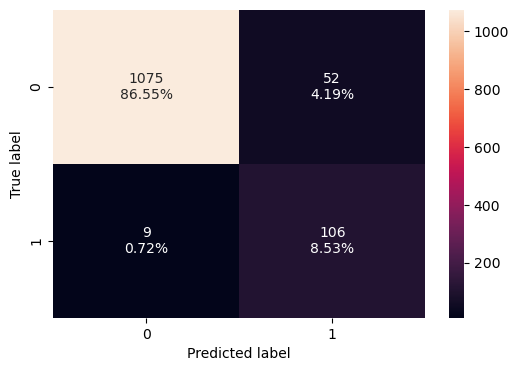

In [80]:
confusion_matrix_sklearn(best_pre_pruned_tree, X_test, y_test)

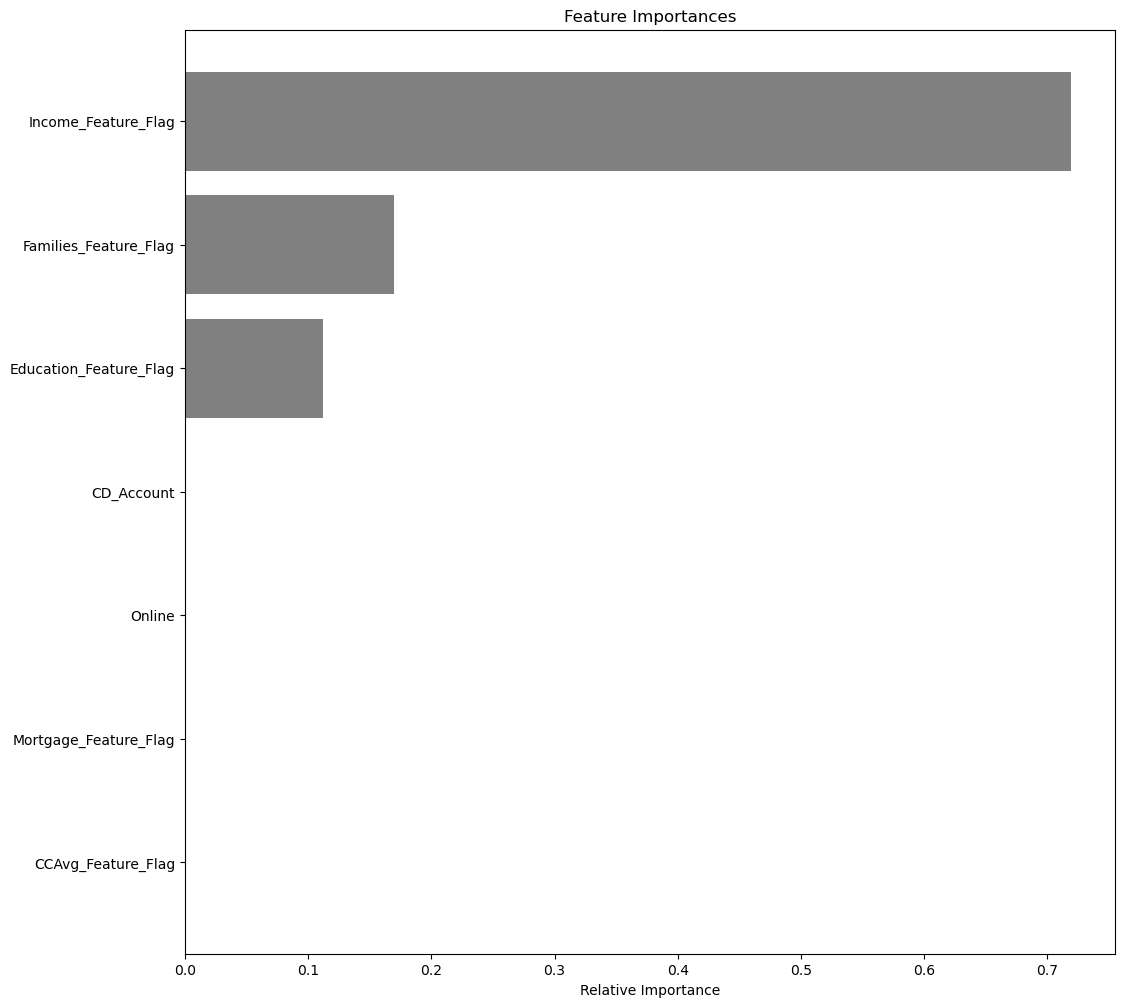

In [81]:
best_pre_pruned_tree_importances = best_pre_pruned_tree.feature_importances_
indices = np.argsort(best_pre_pruned_tree_importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), best_pre_pruned_tree_importances[indices], color="grey", align="center")
plt.yticks(range(len(indices)), [features_list[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

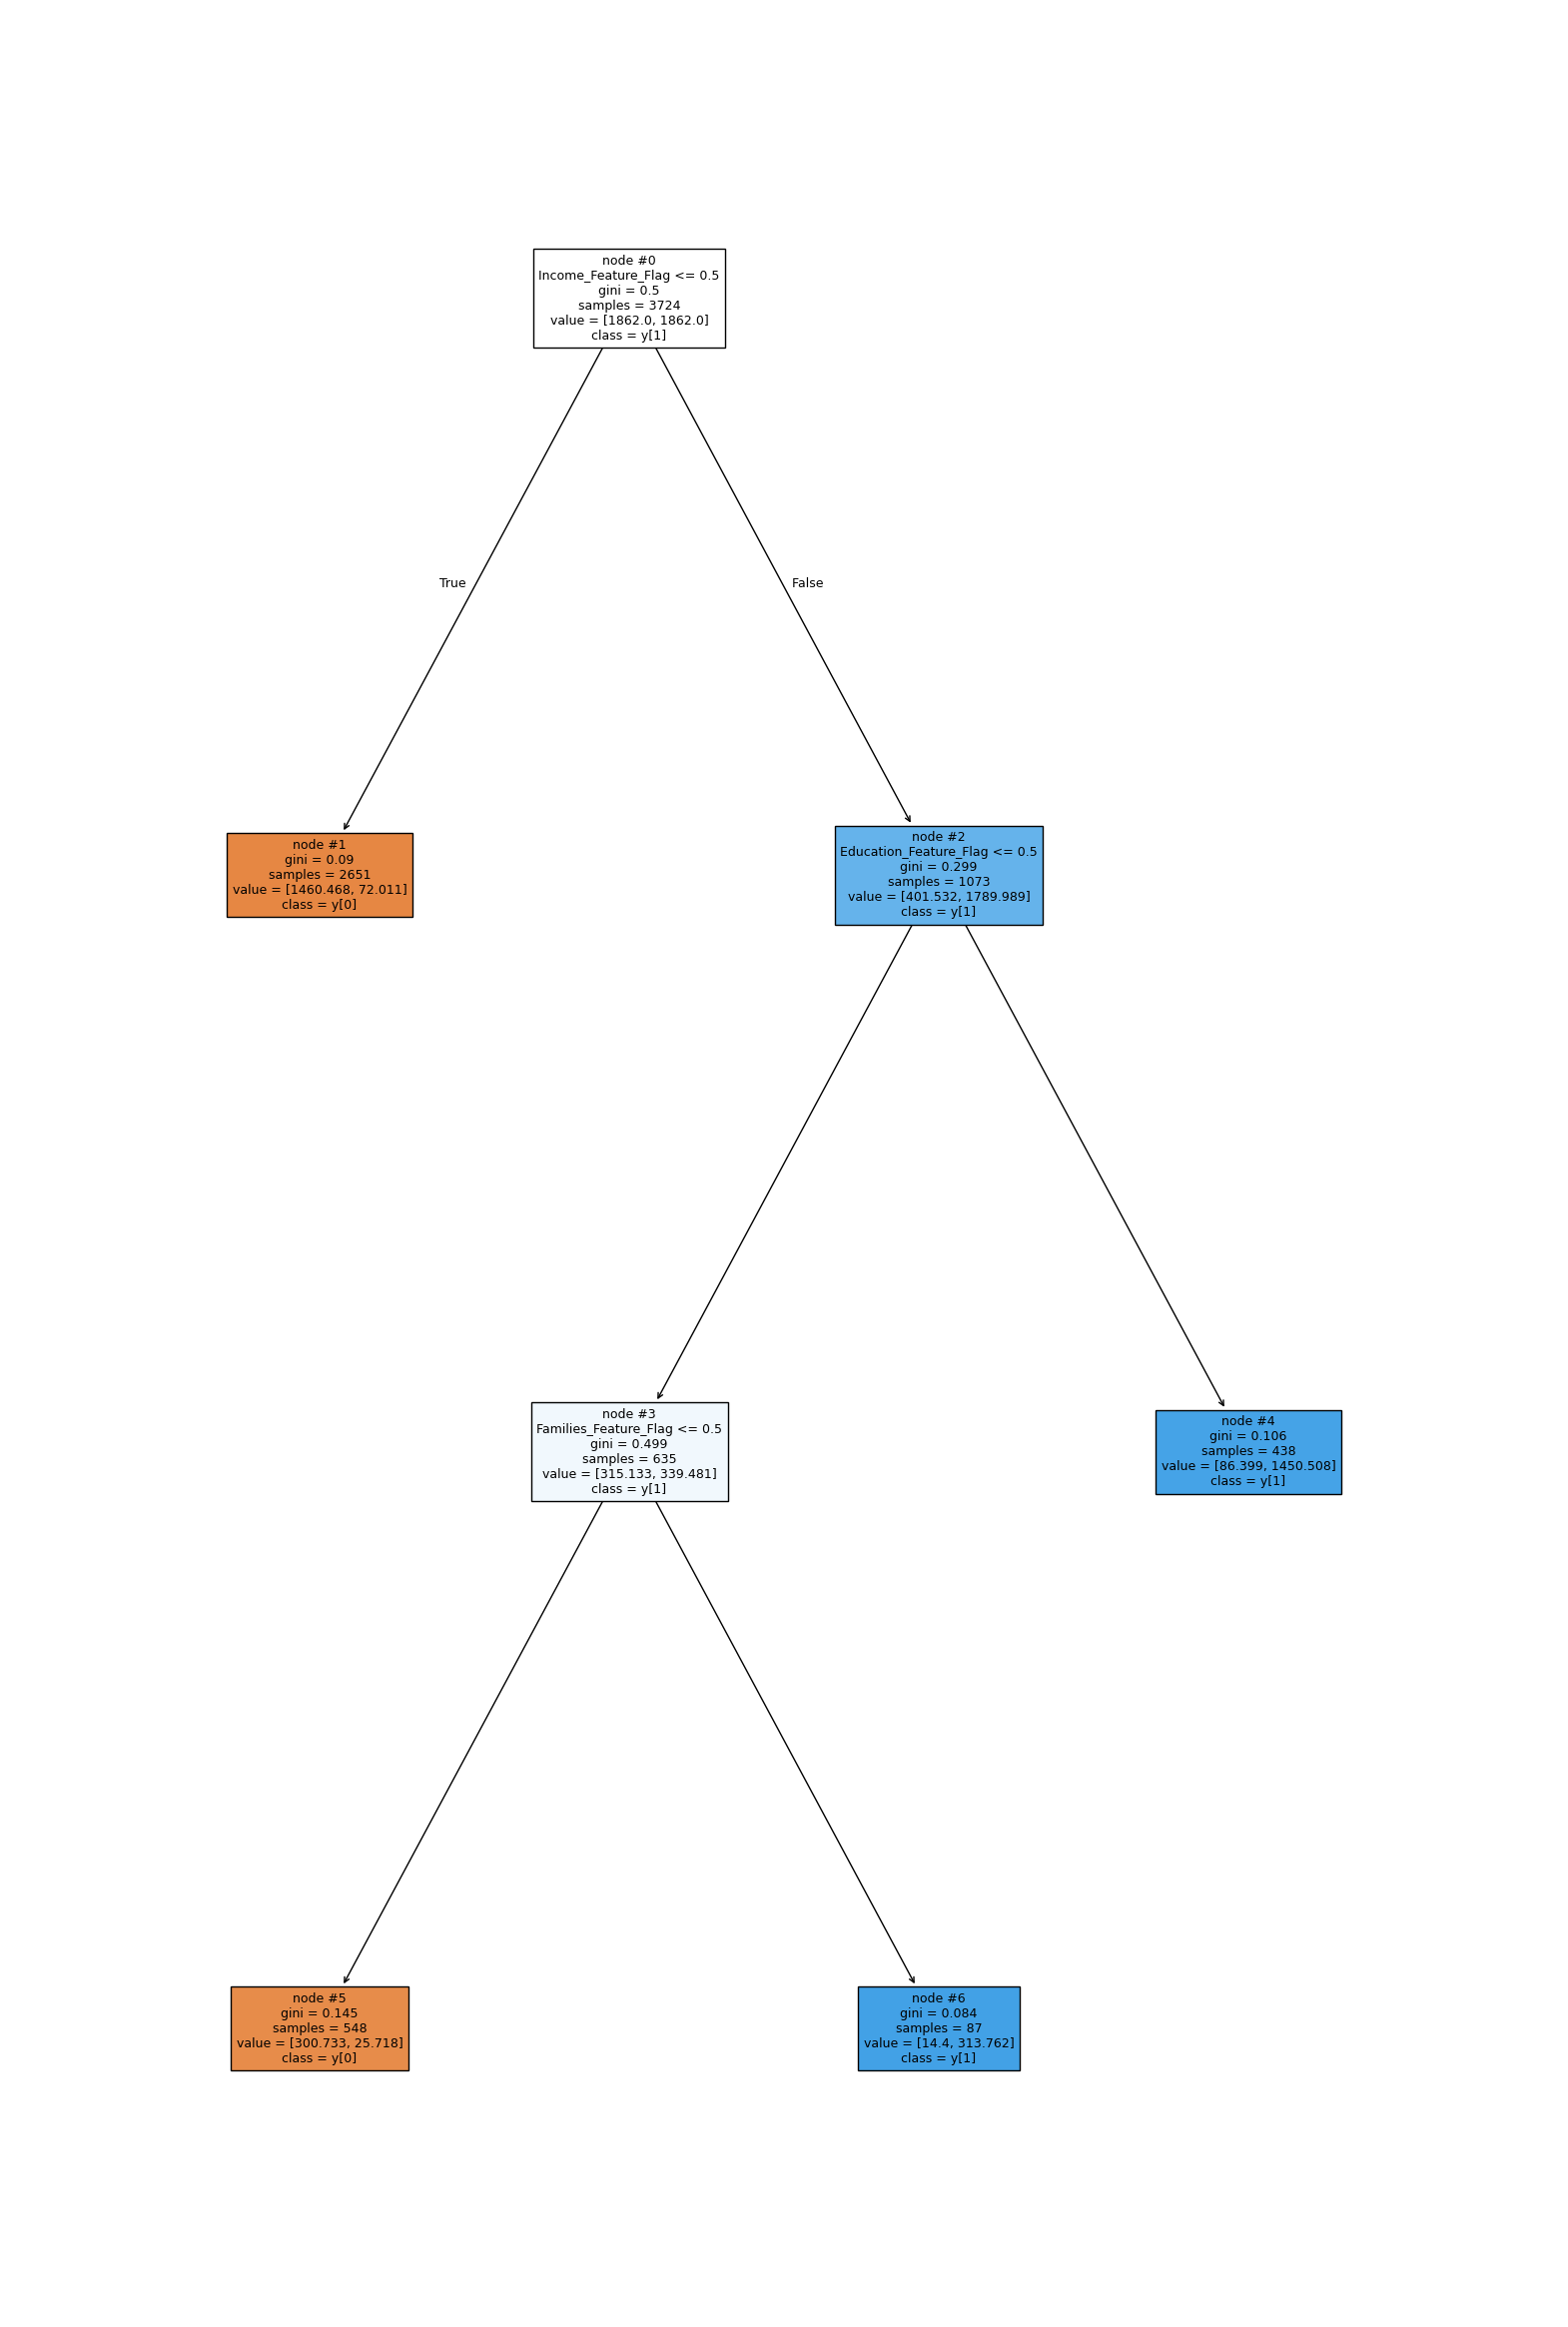

In [82]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    best_pre_pruned_tree,
    feature_names=features_list,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

---
* The model can be described well just using 3 features of Income, Family and Education
* Let's try increasing minimum value of max_depth to 5 and see the difference
---


In [83]:
# Define the parameters of the tree to iterate over
criterion_list=['gini', 'entropy', 'log_loss']
max_depth_list = [5, 6, 7, 8]
min_samples_leaf_list = [12, 24, 48, 96]
min_samples_split_list = [12, 24, 48, 96] # Lowest leaf node has 20
max_leaf_nodes_list = [8, 12, 24, 48, 96]


# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = 10000000.0
best_test_score = 0.0
best_train_score= 0.0

# Iterate over all combinations of the specified parameter values
for criterion in criterion_list:
    for max_depth in max_depth_list:
        for min_samples_leaf in min_samples_leaf_list:
            for min_samples_split in min_samples_split_list:
                for max_leaf_nodes in max_leaf_nodes_list:

                    # Initialize the tree with the current set of parameters
                    estimator = DecisionTreeClassifier(criterion=criterion,
                                                       max_depth=max_depth,
                                                       min_samples_split=min_samples_split,
                                                       min_samples_leaf=min_samples_leaf,
                                                       max_leaf_nodes=max_leaf_nodes,
                                                       class_weight='balanced',
                                                       random_state=42
                                                      )

                    # Fit the model to the training data
                    estimator.fit(X_train, y_train)
        
                    # Make predictions on the training and test sets
                    y_train_pred = estimator.predict(X_train)
                    y_test_pred = estimator.predict(X_test)
        
                    # Calculate F-1 scores for training and test sets
                    train_f1_score = round(f1_score(y_train, y_train_pred), 4)
                    test_f1_score = round(f1_score(y_test, y_test_pred), 4)
                    
                    # Calculate the absolute difference between training and test F-1 scores
                    score_diff = abs(train_f1_score - test_f1_score)
        
                    # Update the best estimator and best score if the current one has a smaller score difference
                    if (score_diff < best_score_diff) & (test_f1_score > best_test_score):
                        best_score_diff = score_diff
                        best_test_score = test_f1_score
                        best_train_score = train_f1_score
                        best_estimator = estimator

# creating an instance of the best model
second_best_pre_pruned_tree = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Criterion: {second_best_pre_pruned_tree.criterion}")
print(f"Max depth: {second_best_pre_pruned_tree.max_depth}")
print(f"Min samples split: {second_best_pre_pruned_tree.min_samples_split}")
print(f"Min samples per leaf: {second_best_pre_pruned_tree.min_samples_leaf}")
print(f"Max leaf nodes: {second_best_pre_pruned_tree.max_leaf_nodes}")
print(f"Best train F-1 score: {best_train_score}")
print(f"Best test F-1 score: {best_test_score}")

Best parameters found:
Criterion: gini
Max depth: 5
Min samples split: 12
Min samples per leaf: 24
Max leaf nodes: 8
Best train F-1 score: 0.7734
Best test F-1 score: 0.7766


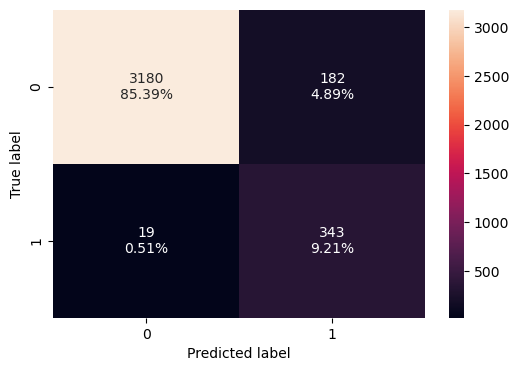

In [84]:
confusion_matrix_sklearn(second_best_pre_pruned_tree, X_train, y_train)

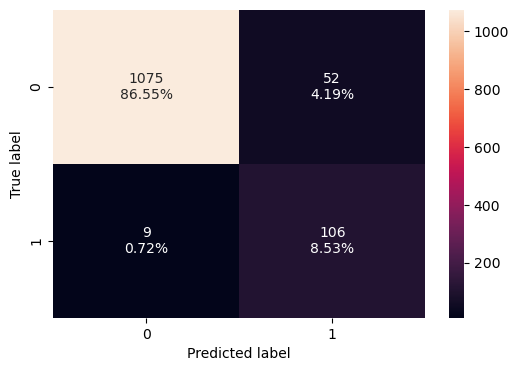

In [85]:
confusion_matrix_sklearn(second_best_pre_pruned_tree, X_test, y_test)

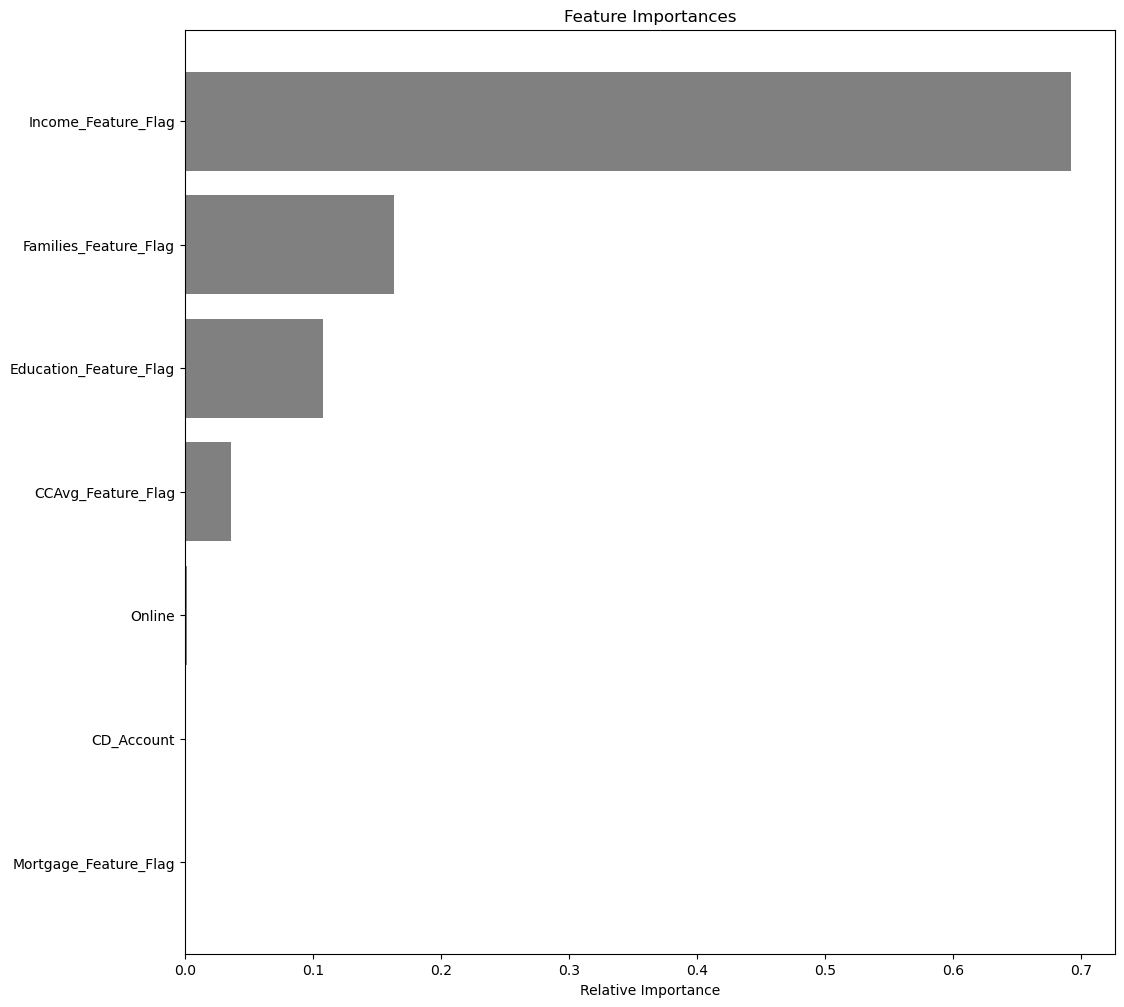

In [86]:
second_best_pre_pruned_tree_importances = second_best_pre_pruned_tree.feature_importances_
indices = np.argsort(second_best_pre_pruned_tree_importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), second_best_pre_pruned_tree_importances[indices], color="grey", align="center")
plt.yticks(range(len(indices)), [features_list[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

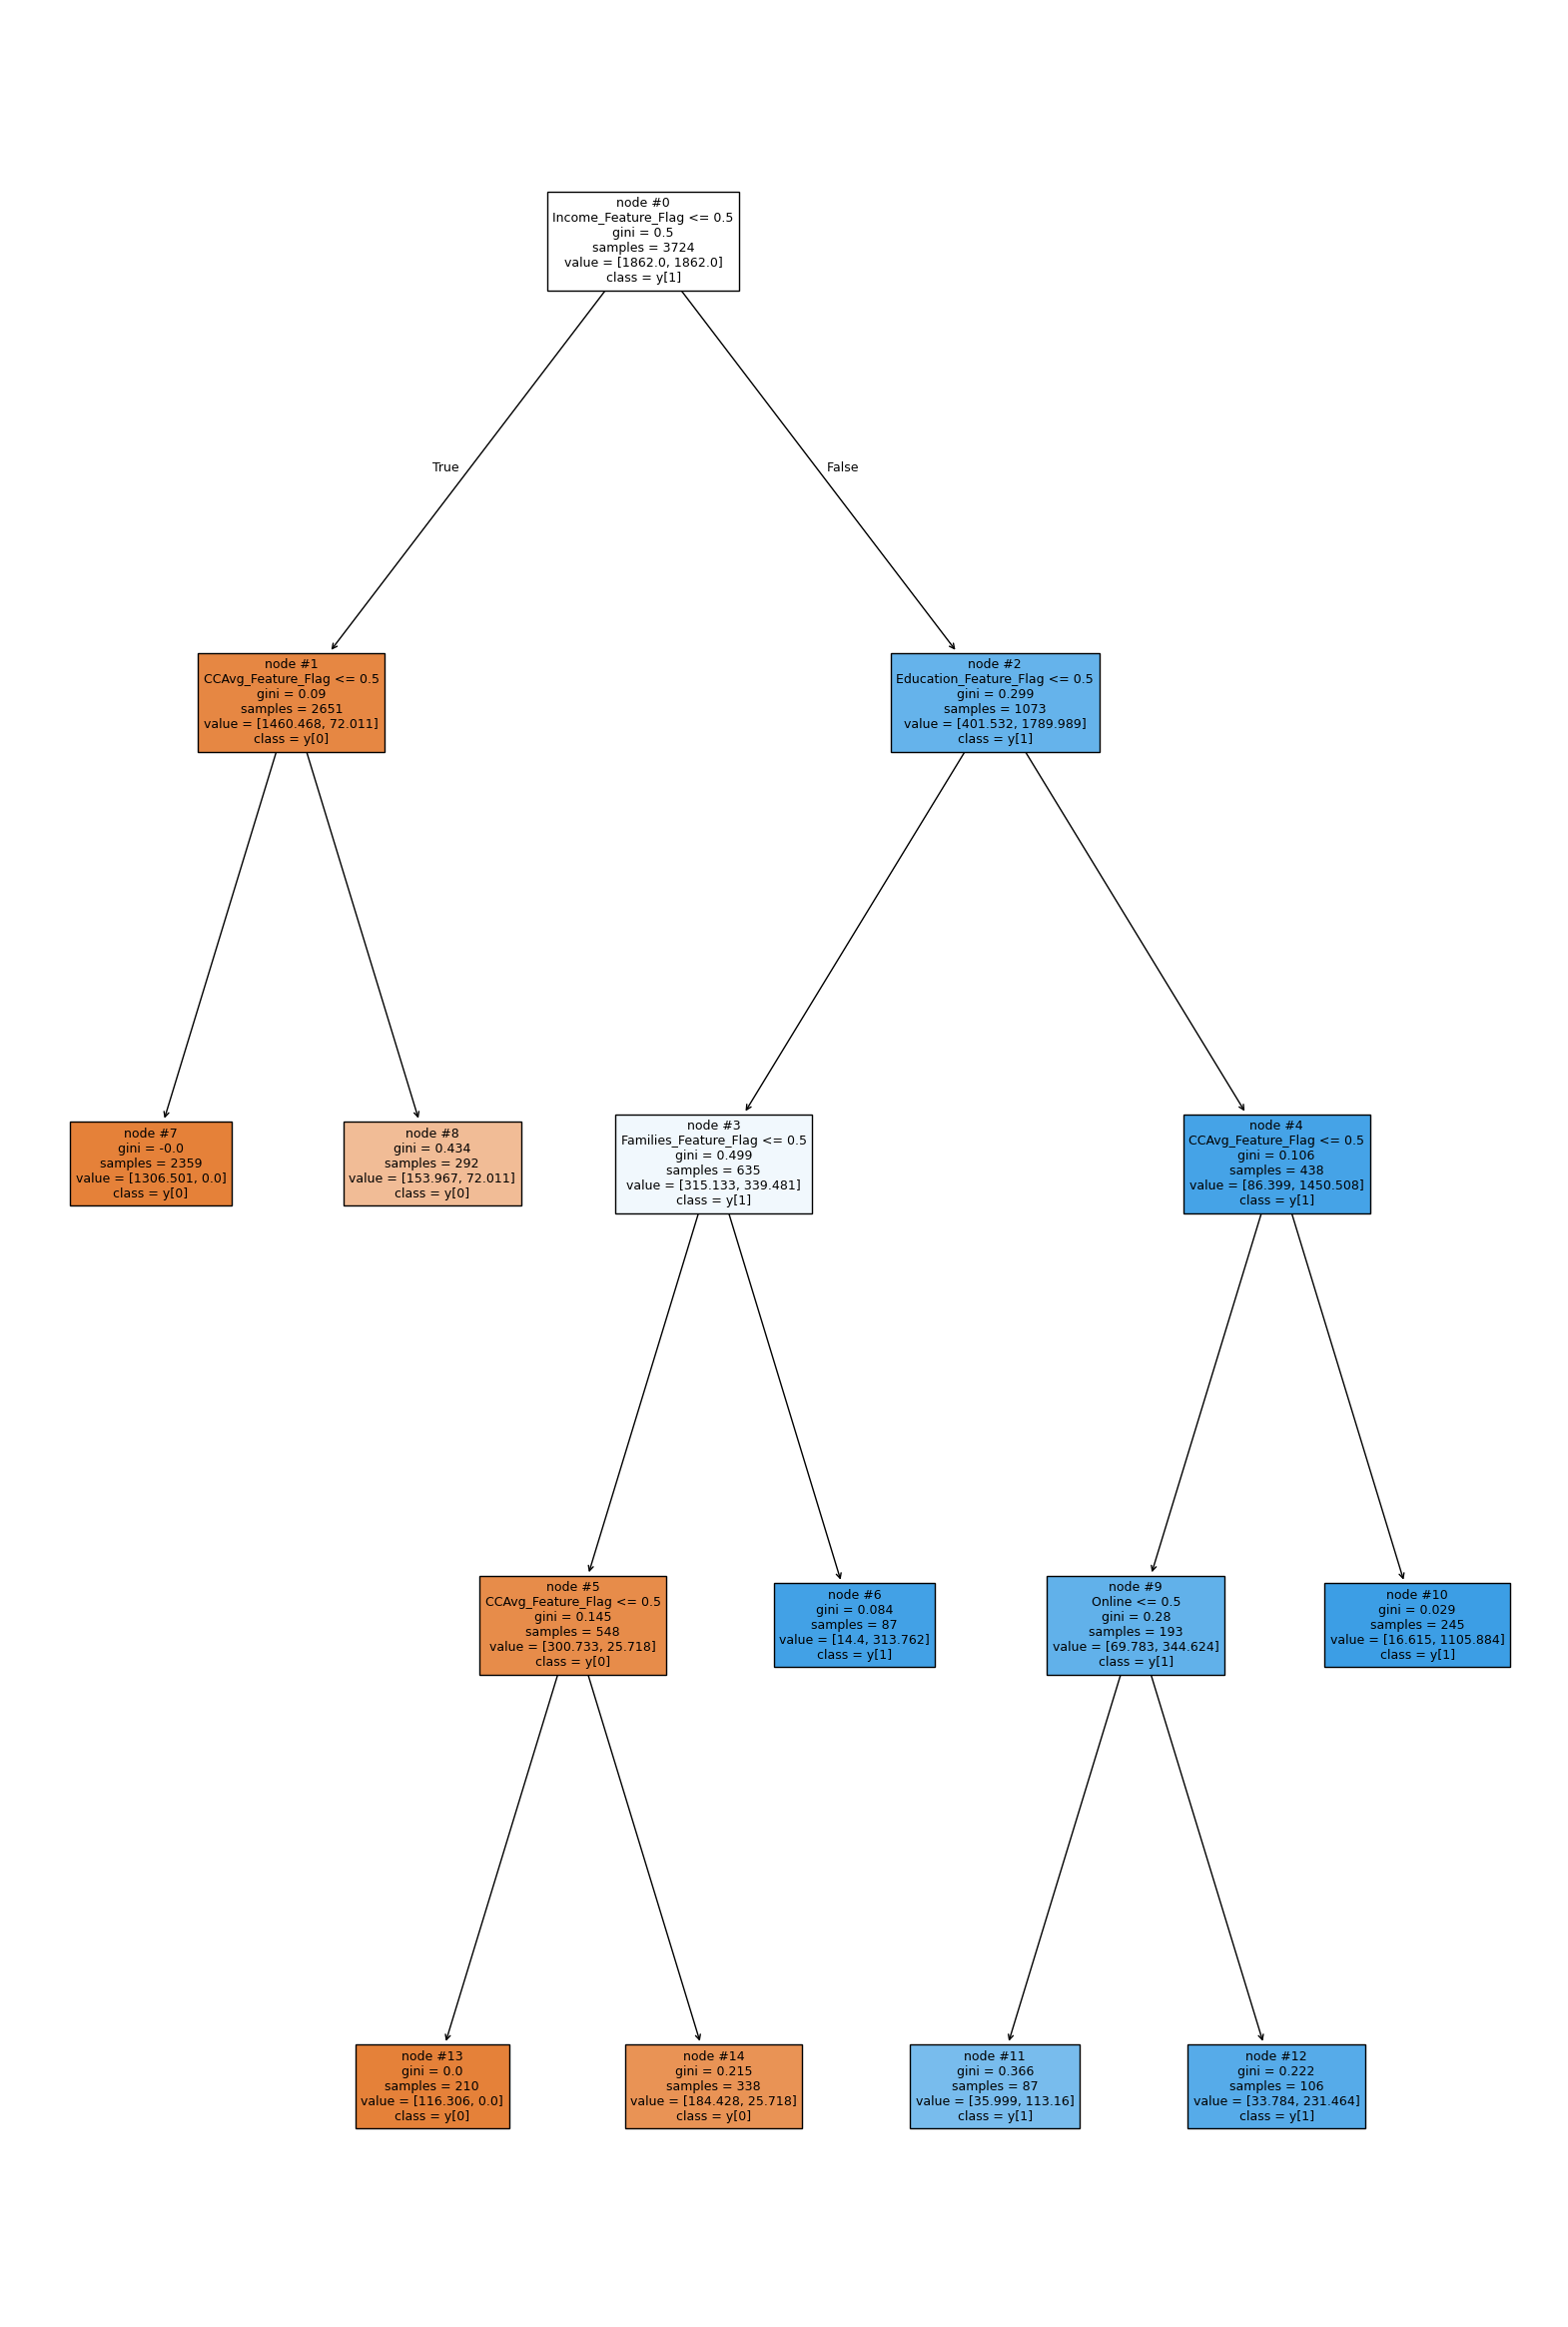

In [87]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    second_best_pre_pruned_tree,
    feature_names=features_list,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

---
* A simple three model decision tree has gained an improvement over the complicated default decision tree
* Default decision tree has poor performance over the training set
* The 3 depth decision tree has similar performance between train and test sets
* To resolve this using GridSearchCV and Cross Validation should help in choosing the best model
* Assuming this is going to be covered in the next project
---

---
#### Post pruning of Decision Tree 

* Utilize cc_alphas parameter to remove leaf nodes which do not contribute to the decision tree classifier
* Use F-1 score metric to find the balance between precision and recall
---

In [88]:
clf = DecisionTreeClassifier(random_state=42, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [89]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.067719
1,8.280669e-18,0.067719
2,3.051297e-17,0.067719
3,1.531330e-09,0.067719
4,1.396152e-07,0.067719
5,5.202089e-07,0.067720
6,8.469116e-07,0.067721
7,1.039055e-06,0.067723
8,1.763667e-06,0.067724
9,2.730776e-06,0.067727


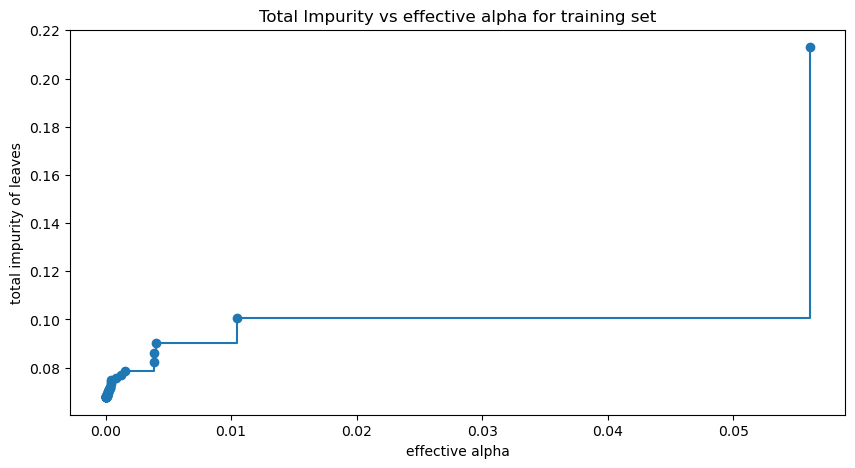

In [90]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [91]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2870085026997672


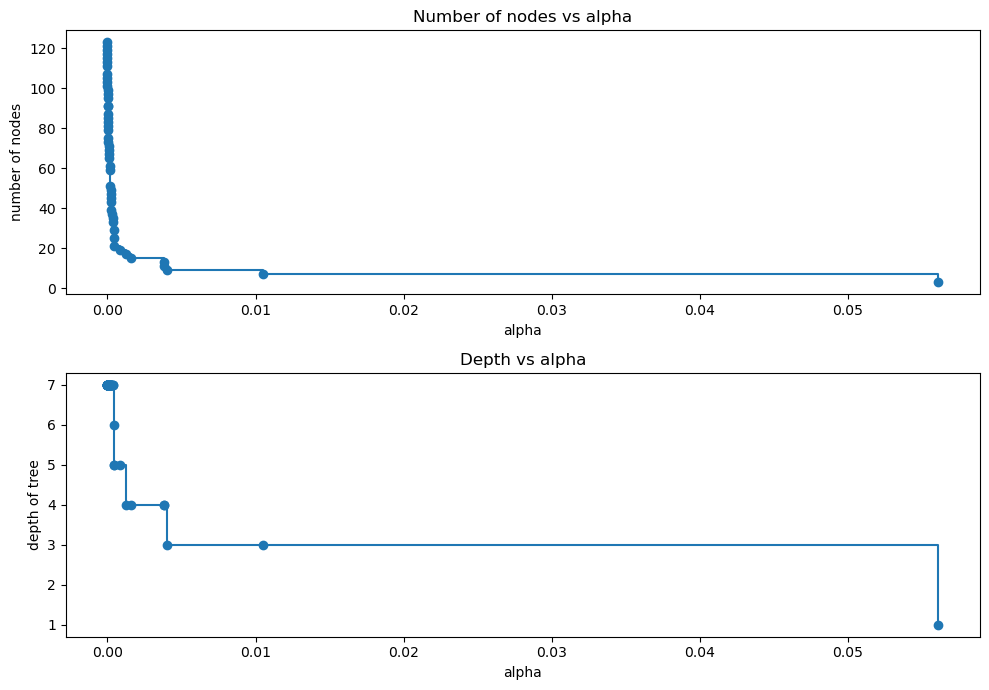

In [92]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [93]:
f1_score_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = f1_score(y_train, pred_train)
    f1_score_train.append(values_train)

In [94]:
f1_score_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = f1_score(y_test, pred_test)
    f1_score_test.append(values_test)

In [95]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

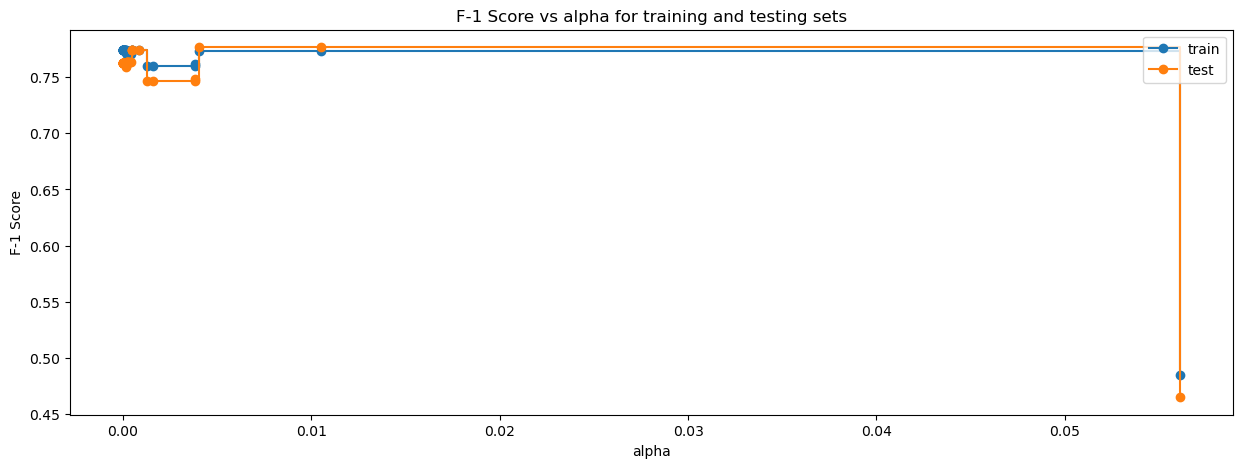

In [96]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("F-1 Score")
ax.set_title("F-1 Score vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, f1_score_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, f1_score_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [97]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(f1_score_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004028238237780488),
                       class_weight='balanced', random_state=42)


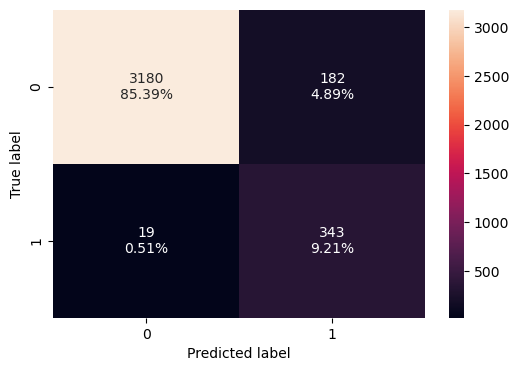

In [98]:
best_post_pruned_tree = best_model
confusion_matrix_sklearn(best_post_pruned_tree, X_train, y_train)

In [99]:
best_post_pruned_tree_post_perf_train = model_performance_classification_sklearn(best_post_pruned_tree, 
                                                                                 X_train, 
                                                                                 y_train
                                                                                 )
best_post_pruned_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.946,0.9475,0.6533,0.7734


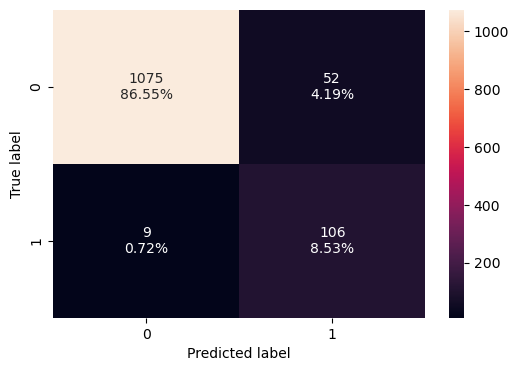

In [100]:
confusion_matrix_sklearn(best_post_pruned_tree, X_test, y_test)

In [101]:
best_post_pruned_tree_post_perf_test = model_performance_classification_sklearn(best_post_pruned_tree, 
                                                                                X_test, 
                                                                                y_test
                                                                                )
best_post_pruned_tree_post_perf_test

,Accuracy,Recall,Precision,F1
0,0.9509,0.9217,0.6709,0.7766


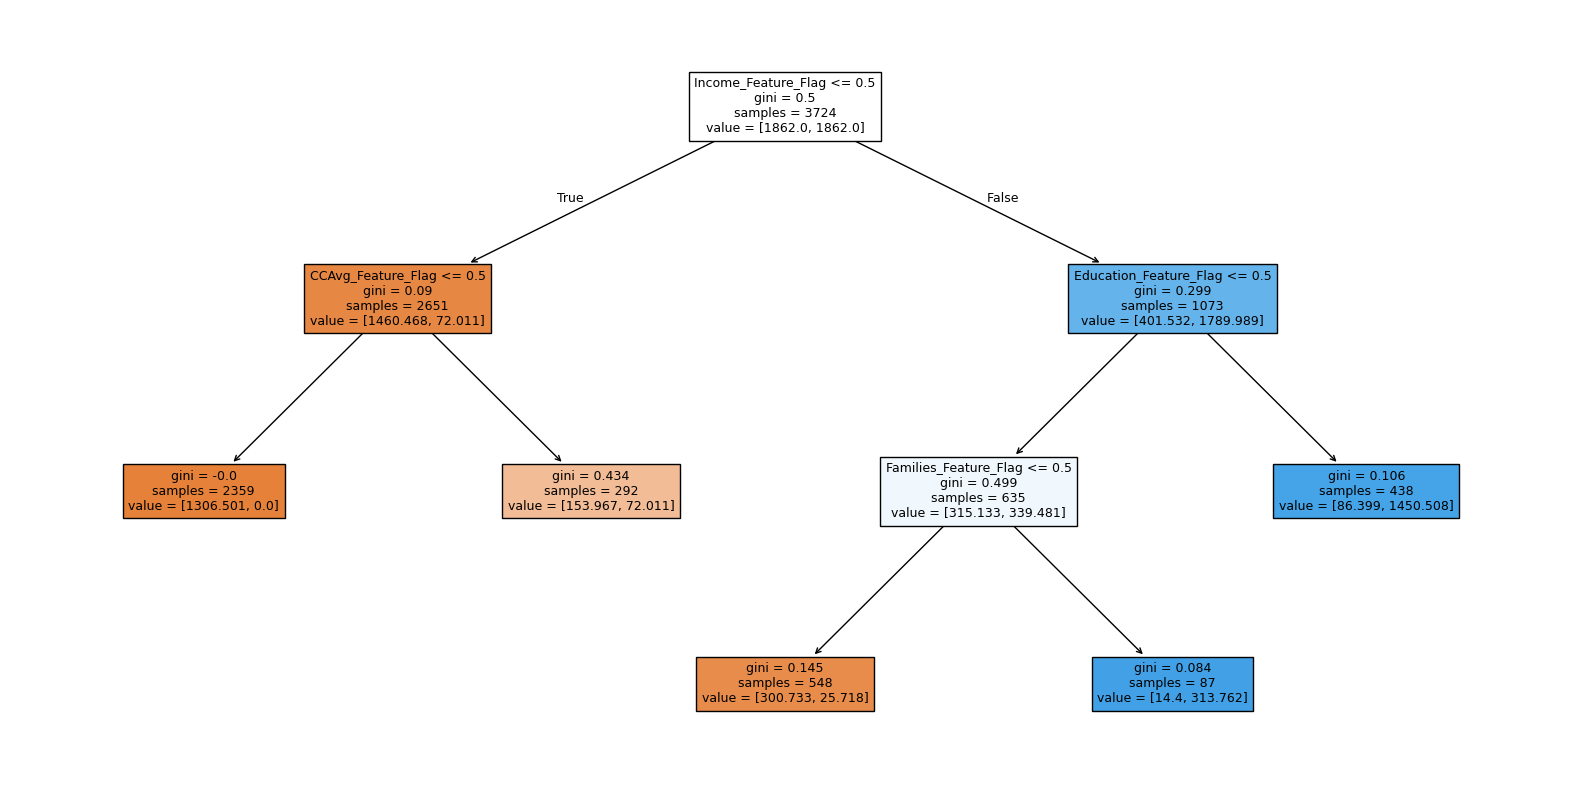

In [102]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    best_post_pruned_tree,
    feature_names=features_list,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [103]:
best_post_pruned_tree_importances = best_post_pruned_tree.feature_importances_
indices = np.argsort(best_post_pruned_tree_importances)

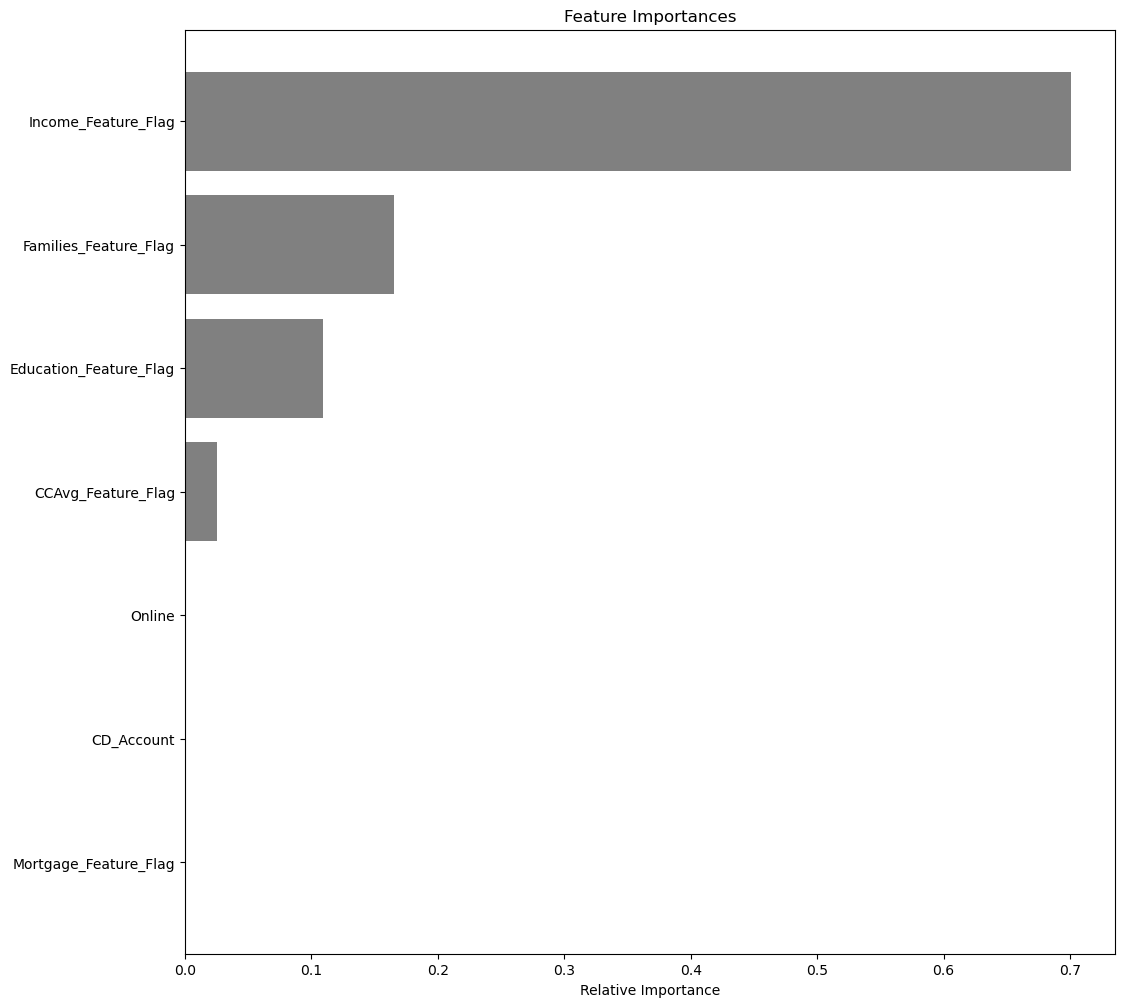

In [104]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), best_post_pruned_tree_importances[indices], color="grey", align="center")
plt.yticks(range(len(indices)), [features_list[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Model Performance Comparison and Final Model Selection

---
* The simplest tree achieved by pre-pruning seems to have the best performance for the decision tree classifier.
     - This in comparison to post-pruned and default decision tree
* If there is a choice between a simple and a complex model having the same performance, best to choose the simpler model.
---

In [105]:
print(tree.export_text(best_post_pruned_tree, feature_names=features_list, show_weights=True))

|--- Income_Feature_Flag <= 0.50
|   |--- CCAvg_Feature_Flag <= 0.50
|   |   |--- weights: [1306.50, 0.00] class: 0
|   |--- CCAvg_Feature_Flag >  0.50
|   |   |--- weights: [153.97, 72.01] class: 0
|--- Income_Feature_Flag >  0.50
|   |--- Education_Feature_Flag <= 0.50
|   |   |--- Families_Feature_Flag <= 0.50
|   |   |   |--- weights: [300.73, 25.72] class: 0
|   |   |--- Families_Feature_Flag >  0.50
|   |   |   |--- weights: [14.40, 313.76] class: 1
|   |--- Education_Feature_Flag >  0.50
|   |   |--- weights: [86.40, 1450.51] class: 1



## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?
  
    - Avoid reaching out to people with income below $90,000
      
    - Reach out to people with income greater than or equal to $90,000 with graduate degrees or advanced degrees
 
    - Reach out to people with income greater than or equal to $90,000 with family sizes of 3 or more

___